### Data Understanding

# Health Outcomes (Targets)

Infant mortality
Under-5 mortality
Maternal mortality

# Disease Burden
Malaria
TB

# Prevention
DPT Immunization
Measles Immunization

# Nutrition
Underweight children
Undernourished population

# Healthcare Capacity
Government expenditure
Physician density
Nurse & Midwife density



| Variable           | Meaning                | Better if Higher? |
| ------------------ | ---------------------- | ----------------- |
| Infant mortality   | Deaths per 1000 births | ❌ No              |
| Under-5 mortality  | Deaths under age 5     | ❌ No              |
| Maternal mortality | Maternal deaths        | ❌ No              |
| Immunization       | Vaccine coverage       | ✅ Yes             |
| Physicians density | Doctors per 1000       | ✅ Yes             |
| Nurse density      | Nurses per 1000        | ✅ Yes             |
| Health expenditure | Spending               | ✅ Yes             |
| TB prevalence      | Disease burden         | ❌ No              |
| Malaria prevalence | Disease burden         | ❌ No              |
| Undernourishment   | Food insecurity        | ❌ No              |

| Variable                      | Meaning                                                                      | Better if Higher? |
| ----------------------------- | ---------------------------------------------------------------------------- | ----------------- |
| Infant mortality              | Number of infant deaths per 1,000 live births                                | No                |
| Under-5 mortality             | Number of deaths of children under age five per 1,000 live births            | No                |
| Maternal mortality            | Number of maternal deaths related to pregnancy or childbirth                 | No                |
| Underweight children          | Percentage of children under five who are moderately or severely underweight | No                |
| Undernourished population     | Percentage of the population experiencing undernourishment                   | No                |
| Measles immunization          | Percentage of one-year-old children immunized against measles                | Yes               |
| DPT immunization              | Percentage of one-year-old children immunized against DPT                    | Yes               |
| Malaria prevalence            | Prevalence of malaria in the population                                      | No                |
| TB prevalence                 | Prevalence of tuberculosis in the population                                 | No                |
| Government health expenditure | Government spending on healthcare                                            | Yes               |
| Physician density             | Number of medical doctors per 1,000 population                               | Yes               |
| Nurses and midwives density   | Number of nurses and midwives per 1,000 population                           | Yes               |
| Pharmaceutical worker density | Number of pharmaceutical personnel per 1,000 population                      | Yes               |


The dataset:

1.goverment_expence_in_health.csv
2.immunization_DPT.csv
3.immunization_measless.csv
4.Infant_mortality_rate.csv
5.malaria_prevalence.csv
6.maternal_mortality_rate.csv
7.nurses _ midwife_density.csv
8.physicans_density.csv
9.TB_Prevalence.csv
10.under_5_mortality_rate.csv
11.undernourished_population.csv
12.underweight_children.csv

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import re
import os
from functools import reduce
import warnings
warnings.filterwarnings('ignore')

### Reading our dataset

In [4]:
data_1 =pd.read_csv('goverment_expence_in_health.csv')
data_2 =pd.read_csv('immunization_DPT.csv')
data_3 =pd.read_csv('immunization_measless.csv')
data_4 =pd.read_csv('Infant_mortality_rate.csv')
data_5 =pd.read_csv('malaria_prevalence.csv')
data_6 =pd.read_csv('maternal_mortality_rate.csv')
data_7 =pd.read_csv('nurses_midwife_density.csv')
data_8 =pd.read_csv('physicans_density.csv')
data_9 =pd.read_csv('TB_Prevalence.csv')
data_10 =pd.read_csv('under_5_mortality_rate.csv')
data_11 =pd.read_csv('undernourished_population.csv')
data_12 =pd.read_csv('underweight_children.csv')

###  Data Preparation

In [83]:
data_2.head()

,Countries and areas,Reference year(s),2004DPT,2005DPT,2006DPT,2007DPT,2008DPT,2009DPT,2010DPT,2011DPT,2012DPT,2013DPT,2014DPT,Source
0,Brunei Darussalam,2004-2014,91.7,99.7,100.0,99.0,99.0,99.0,95.4,97.0,95.4,99.6,99.0,ASEAN Secretariat
1,Cambodia,2004-2014,NaN,NaN,NaN,82.0,82.0,94.0,92.0,94.0,95.0,92.0,97.0,ASEAN Secretariat
2,Indonesia,2004-2014,86.5,84.6,87.1,86.4,86.1,89.1,89.8,89.1,90.0,90.3,90.7,ASEAN Secretariat
3,Lao's PDR,2004-2014,NaN,NaN,NaN,50.0,50.0,57.0,74.0,78.0,79.0,89.0,NaN,ASEAN Secretariat
4,Malaysia,2004-2014,94.2,95.3,96.4,96.0,96.0,95.0,94.0,99.0,99.0,97.0,93.0,ASEAN Secretariat


In [13]:
# Change this to your folder path if needed
DATA_DIR = "."

files = {
    "government_health_expenditure": "goverment_expence_in_health.csv",
    "dpt_immunization": "immunization_DPT.csv",
    "measles_immunization": "immunization_measless.csv",
    "infant_mortality_rate": "Infant_mortality_rate.csv",
    "malaria_prevalence": "malaria_prevalence.csv",
    "maternal_mortality_rate": "maternal_mortality_rate.csv",
    "nurses_midwives_density": "nurses _ midwife_density.csv",
    "physicians_density": "physicans_density.csv",
    "tb_prevalence": "TB_Prevalence.csv",
    "under_5_mortality_rate": "under_5_mortality_rate.csv",
    "undernourished_population": "undernourished_population.csv",
    "underweight_children": "underweight_children.csv"
}

In [14]:
country_map = {
    "Brunei Darussalam*": "Brunei Darussalam",
    "Brunnei Darussalam": "Brunei Darussalam",
    "Lao's PDR": "Lao PDR",
    "Lao PDR": "Lao PDR",
    "Lao People's Democratic Republic": "Lao PDR"
}

def clean_country(x):
    if pd.isna(x):
        return None
    
    x = str(x).strip()
    x = x.replace("*", "")
    x = re.sub(r"\s+", " ", x)
    
    return country_map.get(x, x)

In [15]:
def to_number(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace({"nan": None, "None": None, "": None}),
        errors="coerce"
    )

In [16]:
def tidy_file(path, value_name):
    df = pd.read_csv(path)

    # Identify the country column
    country_col = None
    for col in ["Country", "Countries", "Countries and areas"]:
        if col in df.columns:
            country_col = col
            break

    if country_col is None:
        raise ValueError(f"No country column found in {path}")

    # Case 1: Dataset is already in long format
    if "Year" in df.columns:
        value_cols = [col for col in df.columns if col not in [country_col, "Year"]]

        if len(value_cols) != 1:
            raise ValueError(f"Expected one value column in {path}, found {value_cols}")

        out = df[[country_col, "Year", value_cols[0]]].copy()
        out.columns = ["country", "year", value_name]

    # Case 2: Dataset is in wide format
    else:
        year_cols = [col for col in df.columns if re.match(r"^\d{4}", str(col))]

        out = df[[country_col] + year_cols].melt(
            id_vars=country_col,
            value_vars=year_cols,
            var_name="year",
            value_name=value_name
        )

        out = out.rename(columns={country_col: "country"})

        # Extract year from column names like 2004DPT, 2004TBC, 2004Malaria
        out["year"] = out["year"].astype(str).str.extract(r"^(\d{4})")[0]

    # Clean values
    out["country"] = out["country"].apply(clean_country)
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out[value_name] = to_number(out[value_name])

    # Drop empty country/year rows
    out = out.dropna(subset=["country", "year"])
    out["year"] = out["year"].astype(int)

    # Handle possible duplicates
    out = out.groupby(["country", "year"], as_index=False)[value_name].mean()

    return out

In [18]:
long_dfs = []

for value_name, filename in files.items():
    path = os.path.join(DATA_DIR, filename)
    try:
        tidy_df = tidy_file(path, value_name)
    except FileNotFoundError:
        # try common filename fixes and fuzzy match in DATA_DIR
        candidates = [
            filename.replace(" _ ", "_"),
            filename.replace(" ", "_"),
            filename.replace(" ", ""),
            filename.strip()
        ]
        tidy_df = None
        for fn in candidates:
            alt_path = os.path.join(DATA_DIR, fn)
            if os.path.exists(alt_path):
                tidy_df = tidy_file(alt_path, value_name)
                break
        if tidy_df is None:
            for f in os.listdir(DATA_DIR):
                if f.lower().replace(" ", "").replace("_", "") == filename.lower().replace(" ", "").replace("_", ""):
                    tidy_df = tidy_file(os.path.join(DATA_DIR, f), value_name)
                    break
        if tidy_df is None:
            raise FileNotFoundError(f"Could not find file for '{filename}' in '{DATA_DIR}'")
    long_dfs.append(tidy_df)

    print(
        value_name,
        tidy_df.shape,
        tidy_df["year"].min(),
        tidy_df["year"].max()
    )

government_health_expenditure (160, 3) 2000 2015
dpt_immunization (110, 3) 2004 2014
measles_immunization (110, 3) 2004 2014
infant_mortality_rate (110, 3) 2004 2014
malaria_prevalence (110, 3) 2004 2014
maternal_mortality_rate (110, 3) 2004 2014
nurses_midwives_density (90, 3) 1991 2013
physicians_density (90, 3) 1991 2013
tb_prevalence (110, 3) 2004 2014
under_5_mortality_rate (110, 3) 2004 2014
undernourished_population (250, 3) 1991 2015
underweight_children (250, 3) 1990 2014


In [19]:
master = reduce(
    lambda left, right: pd.merge(left, right, on=["country", "year"], how="outer"),
    long_dfs
)

master = master.sort_values(["country", "year"]).reset_index(drop=True)

In [20]:
master_2004_2014 = master[
    (master["year"] >= 2004) & (master["year"] <= 2014)
].copy()

In [21]:
indicator_cols = [
    col for col in master_2004_2014.columns
    if col not in ["country", "year"]
]

master_2004_2014["available_indicators"] = master_2004_2014[indicator_cols].notna().sum(axis=1)
master_2004_2014["missing_indicators"] = master_2004_2014[indicator_cols].isna().sum(axis=1)

In [22]:
master.to_csv("asean_health_master_all_years.csv", index=False)

master_2004_2014.to_csv(
    "asean_health_master_2004_2014.csv",
    index=False
)

In [23]:
master_2004_2014.head()

,country,year,government_health_expenditure,dpt_immunization,measles_immunization,infant_mortality_rate,malaria_prevalence,maternal_mortality_rate,nurses_midwives_density,physicians_density,tb_prevalence,under_5_mortality_rate,undernourished_population,underweight_children,available_indicators,missing_indicators
14,Brunei Darussalam,2004,13.6,91.7,99.0,8.8,NaN,NaN,5.412,1.302,54.0,9.8,5.0,NaN,9,3
15,Brunei Darussalam,2005,13.8,99.7,97.4,7.4,NaN,14.4,5.543,1.078,224.0,9.5,5.0,35.2,11,1
16,Brunei Darussalam,2006,14.5,100.0,100.0,6.6,NaN,30.4,5.351,1.084,240.0,9.2,5.0,NaN,10,2
17,Brunei Darussalam,2007,19.9,99.0,96.8,7.6,NaN,34.2,5.114,1.050,272.0,9.5,5.0,NaN,10,2
18,Brunei Darussalam,2008,21.2,99.0,97.0,7.0,NaN,0.0,5.097,1.481,286.0,9.5,5.0,NaN,10,2


In [24]:
master_2004_2014.shape

(110, 16)

In [25]:
master_2004_2014.isna().sum().sort_values(ascending=False)

underweight_children             84
malaria_prevalence               54
maternal_mortality_rate          54
nurses_midwives_density          51
physicians_density               50
tb_prevalence                    32
under_5_mortality_rate           31
dpt_immunization                 19
infant_mortality_rate            15
undernourished_population        11
government_health_expenditure     9
measles_immunization              1
year                              0
country                           0
available_indicators              0
missing_indicators                0
dtype: int64

Looking at the missing values

| Column                          | Missing | Approx. % Missing | Decision                                  |
| ------------------------------- | ------: | ----------------: | ----------------------------------------- |
| `underweight_children`          |      84 |               76% | Drop from ML, keep only for EDA if needed |
| `malaria_prevalence`            |      54 |               49% | Keep, but impute carefully                |
| `maternal_mortality_rate`       |      54 |               49% | Keep, important for SDG 3                 |
| `nurses_midwives_density`       |      51 |               46% | Keep, important for health capacity       |
| `physicians_density`            |      50 |               45% | Keep, important for health capacity       |
| `tb_prevalence`                 |      32 |               29% | Keep                                      |
| `under_5_mortality_rate`        |      31 |               28% | Keep                                      |
| `dpt_immunization`              |      19 |               17% | Keep                                      |
| `infant_mortality_rate`         |      15 |               14% | Keep                                      |
| `undernourished_population`     |      11 |               10% | Keep                                      |
| `government_health_expenditure` |       9 |                8% | Keep                                      |
| `measles_immunization`          |       1 |                1% | Keep                                      |


In [27]:
missing_summary = pd.DataFrame({
    "missing_count": master_2004_2014.isna().sum(),
    "missing_percent": master_2004_2014.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
underweight_children,84,76.363636
malaria_prevalence,54,49.090909
maternal_mortality_rate,54,49.090909
nurses_midwives_density,51,46.363636
physicians_density,50,45.454545
tb_prevalence,32,29.090909
under_5_mortality_rate,31,28.181818
dpt_immunization,19,17.272727
infant_mortality_rate,15,13.636364
undernourished_population,11,10.000000


In [29]:
master_2004_2014 = master_2004_2014.drop(columns=["underweight_children"])

In [31]:
master_2004_2014 = master_2004_2014.drop(columns=["available_indicators", "missing_indicators"])

Interpolate Missing Values by Country

In [32]:
indicator_cols = [
    col for col in master_2004_2014.columns 
    if col not in ["country", "year"]
]

df_model = master_2004_2014 .sort_values(["country", "year"])

df_model[indicator_cols] = (
    df_model
    .groupby("country")[indicator_cols]
    .transform(lambda group: group.interpolate(method="linear", limit_direction="both"))
)

In [33]:
for col in indicator_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

In [34]:
df_model.isna().sum().sort_values(ascending=False)

country                          0
year                             0
government_health_expenditure    0
dpt_immunization                 0
measles_immunization             0
infant_mortality_rate            0
malaria_prevalence               0
maternal_mortality_rate          0
nurses_midwives_density          0
physicians_density               0
tb_prevalence                    0
under_5_mortality_rate           0
undernourished_population        0
dtype: int64

In [35]:
df_model.to_csv("asean_health_cleaned_for_ml.csv", index=False)

In [36]:
df_model.head()

,country,year,government_health_expenditure,dpt_immunization,measles_immunization,infant_mortality_rate,malaria_prevalence,maternal_mortality_rate,nurses_midwives_density,physicians_density,tb_prevalence,under_5_mortality_rate,undernourished_population
14,Brunei Darussalam,2004,13.6,91.7,99.0,8.8,34.8,14.4,5.412,1.302,54.0,9.8,5.0
15,Brunei Darussalam,2005,13.8,99.7,97.4,7.4,34.8,14.4,5.543,1.078,224.0,9.5,5.0
16,Brunei Darussalam,2006,14.5,100.0,100.0,6.6,34.8,30.4,5.351,1.084,240.0,9.2,5.0
17,Brunei Darussalam,2007,19.9,99.0,96.8,7.6,34.8,34.2,5.114,1.050,272.0,9.5,5.0
18,Brunei Darussalam,2008,21.2,99.0,97.0,7.0,34.8,0.0,5.097,1.481,286.0,9.5,5.0


In [37]:
df_model.isna().sum()

country                          0
year                             0
government_health_expenditure    0
dpt_immunization                 0
measles_immunization             0
infant_mortality_rate            0
malaria_prevalence               0
maternal_mortality_rate          0
nurses_midwives_density          0
physicians_density               0
tb_prevalence                    0
under_5_mortality_rate           0
undernourished_population        0
dtype: int64

In [40]:
df_model.columns

Index(['country', 'year', 'government_health_expenditure', 'dpt_immunization',
       'measles_immunization', 'infant_mortality_rate', 'malaria_prevalence',
       'maternal_mortality_rate', 'nurses_midwives_density',
       'physicians_density', 'tb_prevalence', 'under_5_mortality_rate',
       'undernourished_population'],
      dtype='object')

Raw datasets
    ↓
Cleaned individual files
    ↓
Merged country-year dataset
    ↓
Missing values handled
    ↓
Clean ML-ready dataset:

Health Risk score
    ↓
Health Readiness score
    ↓
Risk classification
    ↓
EDA charts
    ↓
ML model
    ↓
AI recommendations
    ↓
Streamlit app
    ↓
Final presentation

What Problem Are We Solving?

ASEAN countries have health data, but the problem is that the data is usually scattered.

One file shows:

Government health expenditure

Another file shows:

Infant mortality

Another shows:

TB prevalence

Another shows:

Nurses and midwives density


But decision-makers need everything together.

They need to know:

“Which country is most vulnerable?”

“Why is that country vulnerable?”

“Is the problem caused by disease, low immunization, poor health spending, few doctors, undernutrition, or maternal health risk?”

“What should we do first?”

That is what our solution answers.

Health Risk Index:

Infant mortality
Under-5 mortality
Maternal mortality
Malaria prevalence
TB prevalence
Undernourished population


A country with high child mortality, high maternal mortality, high disease burden, and high undernourishment should have a higher health risk score.

In [41]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [63]:
# Make a copy
health_df = df_model.copy()

Define the Health Risk Indicators

These are the bad indicators.

Higher value = worse health condition.

In [64]:
risk_indicators = [
    "infant_mortality_rate",
    "under_5_mortality_rate",
    "maternal_mortality_rate",
    "malaria_prevalence",
    "tb_prevalence",
    "undernourished_population"
]

Health System Readiness Indicators

These are the good indicators.

Higher value = stronger health system.

In [65]:
readiness_indicators = [
    "government_health_expenditure",
    "dpt_immunization",
    "measles_immunization",
    "nurses_midwives_density",
    "physicians_density"
]

In [66]:
required_columns = risk_indicators + readiness_indicators

missing_columns = [col for col in required_columns if col not in health_df.columns]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


Create the Health Risk Index
Logic

For these indicators:

Higher value = higher risk

So we scale them and average them.

In [68]:
risk_scaler = MinMaxScaler()

risk_scaled_cols = [col + "_risk_scaled" for col in risk_indicators]

health_df[risk_scaled_cols] = risk_scaler.fit_transform(
    health_df[risk_indicators]
)

health_df["health_risk_score"] = health_df[risk_scaled_cols].mean(axis=1) * 100

Create Health Risk Level: Low, Medium, High

Use quantiles so the categories are balanced.

In [69]:
health_df["health_risk_level"] = pd.qcut(
    health_df["health_risk_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

Health System Readiness Score
Logic

For these indicators:

Higher value = stronger readiness

So we scale them and average them.

In [70]:
readiness_scaler = MinMaxScaler()

readiness_scaled_cols = [col + "_readiness_scaled" for col in readiness_indicators]

health_df[readiness_scaled_cols] = readiness_scaler.fit_transform(
    health_df[readiness_indicators]
)

health_df["readiness_score"] = health_df[readiness_scaled_cols].mean(axis=1) * 100

In [71]:
readiness_scaler = MinMaxScaler()

readiness_scaled_cols = [col + "_readiness_scaled" for col in readiness_indicators]

health_df[readiness_scaled_cols] = readiness_scaler.fit_transform(
    health_df[readiness_indicators]
)

health_df["readiness_score"] = health_df[readiness_scaled_cols].mean(axis=1) * 100

Create Readiness Level: Low, Medium, High

In [72]:
health_df["readiness_level"] = pd.qcut(
    health_df["readiness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

Create the Risk–Readiness Priority Matrix

In [73]:
def assign_priority(row):
    risk = row["health_risk_level"]
    readiness = row["readiness_level"]

    if risk == "High" and readiness == "Low":
        return "Emergency Priority"

    elif risk == "High" and readiness == "Medium":
        return "High Priority"

    elif risk == "High" and readiness == "High":
        return "Monitor Closely"

    elif risk == "Medium" and readiness == "Low":
        return "Preventive Priority"

    elif risk == "Medium" and readiness == "Medium":
        return "Moderate Priority"

    elif risk == "Medium" and readiness == "High":
        return "Controlled Risk"

    elif risk == "Low" and readiness == "Low":
        return "Capacity Building Needed"

    elif risk == "Low" and readiness == "Medium":
        return "Stable but Needs Support"

    elif risk == "Low" and readiness == "High":
        return "Stable / Resilient"

    else:
        return "Unclassified"

In [74]:
health_df["priority_category"] = health_df.apply(assign_priority, axis=1)

In [85]:
health_df[
    [
        "country",
        "year",
        "health_risk_score",
        "health_risk_level",
        "readiness_score",
        "readiness_level",
        "priority_category"
    ]
].tail(20)

,country,year,health_risk_score,health_risk_level,readiness_score,readiness_level,priority_category
224,Thailand,2006,7.105039,Medium,46.267731,Medium,Moderate Priority
225,Thailand,2007,6.452098,Medium,46.924819,Medium,Moderate Priority
226,Thailand,2008,6.019317,Medium,49.936861,Medium,Moderate Priority
227,Thailand,2009,5.693815,Medium,51.820116,Medium,Moderate Priority
228,Thailand,2010,5.636874,Low,52.764408,Medium,Stable but Needs Support
229,Thailand,2011,5.040725,Low,58.098994,High,Stable / Resilient
230,Thailand,2012,5.606791,Low,61.156638,High,Stable / Resilient
231,Thailand,2013,5.760135,Medium,58.269671,High,Controlled Risk
232,Thailand,2014,5.569113,Low,58.250091,High,Stable / Resilient
248,Viet Nam,2004,19.996373,Medium,50.451558,Medium,Moderate Priority


Check the Distribution
Health Risk Distribution

In [77]:
health_df["health_risk_level"].value_counts()

health_risk_level
Low       37
High      37
Medium    36
Name: count, dtype: int64

Readiness Distribution

In [78]:
health_df["readiness_level"].value_counts()

readiness_level
Low       37
High      37
Medium    36
Name: count, dtype: int64

Priority Category Distribution

In [79]:
health_df["priority_category"].value_counts()

priority_category
Emergency Priority          34
Stable / Resilient          31
Moderate Priority           27
Controlled Risk              6
Stable but Needs Support     6
High Priority                3
Preventive Priority          3
Name: count, dtype: int64

Sort by Most Urgent Countries

In [81]:
priority_order = {
    "Emergency Priority": 1,
    "High Priority": 2,
    "Preventive Priority": 3,
    "Monitor Closely": 4,
    "Moderate Priority": 5,
    "Capacity Building Needed": 6,
    "Controlled Risk": 7,
    "Stable but Needs Support": 8,
    "Stable / Resilient": 9
}

health_df["priority_rank"] = health_df["priority_category"].map(priority_order)

urgent_cases = health_df.sort_values(
    by=["priority_rank", "health_risk_score"],
    ascending=[True, False]
)

urgent_cases[
    [
        "country",
        "year",
        "health_risk_score",
        "health_risk_level",
        "readiness_score",
        "readiness_level",
        "priority_category"
    ]
].head(10)

,country,year,health_risk_score,health_risk_level,readiness_score,readiness_level,priority_category
92,Lao PDR,2004,77.993391,High,3.381166,Low,Emergency Priority
93,Lao PDR,2005,73.536930,High,12.897561,Low,Emergency Priority
40,Cambodia,2004,72.161822,High,28.026846,Low,Emergency Priority
94,Lao PDR,2006,70.051266,High,6.010420,Low,Emergency Priority
41,Cambodia,2005,66.042624,High,27.051831,Low,Emergency Priority
42,Cambodia,2006,65.425571,High,27.444453,Low,Emergency Priority
95,Lao PDR,2007,64.285752,High,3.185778,Low,Emergency Priority
43,Cambodia,2007,60.802006,High,29.374747,Low,Emergency Priority
96,Lao PDR,2008,58.785936,High,2.861137,Low,Emergency Priority
144,Myanmar,2004,55.814412,High,28.562056,Low,Emergency Priority


In [82]:
health_df.to_csv("asean_health_risk_readiness_priority.csv", index=False)

The Health Risk Index was created to measure the direct public health burden faced by each ASEAN country-year observation. It was built using six danger indicators: 

infant mortality rate, 
under-5 mortality rate, 
maternal mortality rate, 
malaria prevalence, 
tuberculosis prevalence, and 
undernourished population. 

Since higher values of these indicators represent worse health outcomes, each variable was normalized using Min-Max scaling and averaged to generate a 0–100 Health Risk Score. 
The score was then categorized into Low, Medium, and High risk levels.

The Health System Readiness Score was created separately to measure each country’s capacity to prevent and respond to health challenges. 
It was built using:
 government health expenditure, 
 DPT immunization, 
 measles immunization, 
 nurses/midwives density, and 
 physicians density. 
 
Since higher values represent stronger health system capacity, these indicators were normalized and averaged to generate a 0–100 Readiness Score. 
 
The score was also categorized into Low, Medium, and High readiness levels.

Finally, the Health Risk Level and Health System Readiness Level were combined to create a 
Risk–Readiness Priority Matrix. 

Countries with High Health Risk and Low Readiness were classified as Emergency Priority, while countries with Low Health Risk and High Readiness were classified as Stable / Resilient. This matrix helps policymakers identify not only where health risks are severe, but also where health systems may be least prepared to respond.


### Exploratort Data Analysis (EDA)

EDA is not just for random charts.

Our EDA will validate the logic of the solution.

We will check:

1. Which countries have the highest health risk?
2. Which countries have the lowest readiness?
3. Which countries fall into Emergency Priority?
4. How has risk changed from 2004 to 2014?
5. Which indicators are most associated with high risk?
6. Does low readiness appear connected to high risk?
7. Are our risk categories reasonable?

1: Which countries have the highest health risk?

This EDA question helps us identify which ASEAN countries have the highest average public health burden across the period. This connects directly to the SDG 3 focus on maternal and child mortality, communicable diseases, and health access gaps.

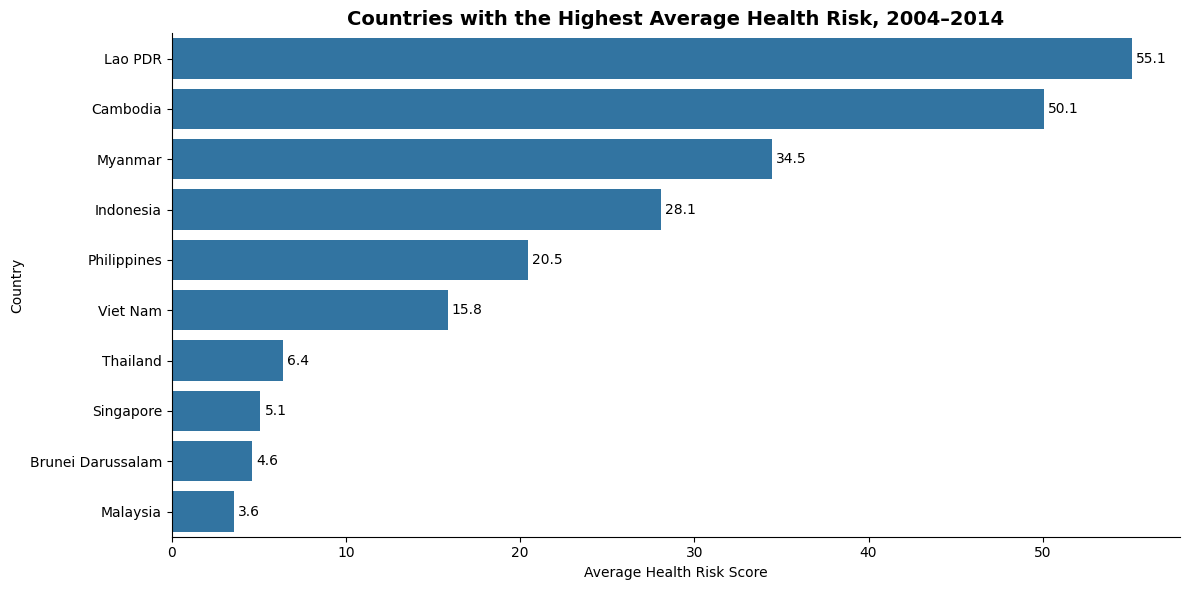

In [91]:
country_risk = (
    health_df
    .groupby("country", as_index=False)
    .agg(
        avg_health_risk_score=("health_risk_score", "mean"),
        min_health_risk_score=("health_risk_score", "min"),
        max_health_risk_score=("health_risk_score", "max")
    )
    .sort_values("avg_health_risk_score", ascending=False)
)


country_risk["avg_risk_level"] = pd.qcut(
    country_risk["avg_health_risk_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)


top_5_risk = country_risk.head(5)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=country_risk,
    x="avg_health_risk_score",
    y="country"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.title("Countries with the Highest Average Health Risk, 2004–2014", fontsize=14, fontweight="bold")
plt.xlabel("Average Health Risk Score")
plt.ylabel("Country")
plt.tight_layout()
sns.despine()
plt.show()

### Insight:
The analysis shows that countries with the highest average Health Risk Score are the most vulnerable to public health challenges across the 2004–2014 period. 

These countries are likely experiencing a heavier burden of child mortality, maternal mortality, communicable diseases, and undernourishment. A high average score suggests that health risk is not just a one-year issue, but a persistent structural challenge requiring targeted policy intervention.

lao PDR, Cambodia and Myanmar recorded the highest average Health Risk Scores between 2004 and 2014. This suggests that these countries faced the most persistent public health burden in the region. Their high scores are likely driven by a combination of higher infant mortality, under-5 mortality, maternal mortality, communicable disease prevalence, and undernourishment. These countries should be prioritized for deeper investigation in the next stage of the analysis.


2. Which countries have the lowest readiness?

This EDA checks which ASEAN countries have the weakest health system capacity based on:

government_health_expenditure
dpt_immunization
measles_immunization
nurses_midwives_density
physicians_density


The goal is to identify countries that may struggle to respond to health risks even before we look at emergency priority.

In [ ]:
# ------------------------------------------------------------
# 2. Confirm required columns
# ------------------------------------------------------------

required_cols = [
    "country",
    "year",
    "readiness_score",
    "readiness_level"
]

missing_cols = [col for col in required_cols if col not in health_df.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are available.")

# ------------------------------------------------------------
# 3. Calculate average readiness by country
# ------------------------------------------------------------

country_readiness = (
    health_df
    .groupby("country", as_index=False)
    .agg(
        avg_readiness_score=("readiness_score", "mean"),
        min_readiness_score=("readiness_score", "min"),
        max_readiness_score=("readiness_score", "max")
    )
    .sort_values("avg_readiness_score", ascending=True)
)

country_readiness

All required columns are available.


,country,avg_readiness_score,min_readiness_score,max_readiness_score
3,Lao PDR,15.761217,2.861137,32.556521
1,Cambodia,32.814128,27.051831,38.605939
5,Myanmar,33.852487,23.159765,42.634259
2,Indonesia,39.764095,28.555846,51.600670
8,Thailand,52.118645,44.667636,61.156638
9,Viet Nam,54.837390,47.794090,60.682341
6,Philippines,56.670222,52.641892,63.856836
4,Malaysia,58.793707,46.458683,69.702336
0,Brunei Darussalam,67.098467,60.853821,73.917200
7,Singapore,70.352238,62.197998,81.042520


In [93]:
# ------------------------------------------------------------
# 4. Add average readiness level
# ------------------------------------------------------------

country_readiness["avg_readiness_level"] = pd.qcut(
    country_readiness["avg_readiness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

country_readiness

,country,avg_readiness_score,min_readiness_score,max_readiness_score,avg_readiness_level
3,Lao PDR,15.761217,2.861137,32.556521,Low
1,Cambodia,32.814128,27.051831,38.605939,Low
5,Myanmar,33.852487,23.159765,42.634259,Low
2,Indonesia,39.764095,28.555846,51.600670,Medium
8,Thailand,52.118645,44.667636,61.156638,Medium
9,Viet Nam,54.837390,47.794090,60.682341,Medium
6,Philippines,56.670222,52.641892,63.856836,Medium
4,Malaysia,58.793707,46.458683,69.702336,High
0,Brunei Darussalam,67.098467,60.853821,73.917200,High
7,Singapore,70.352238,62.197998,81.042520,High


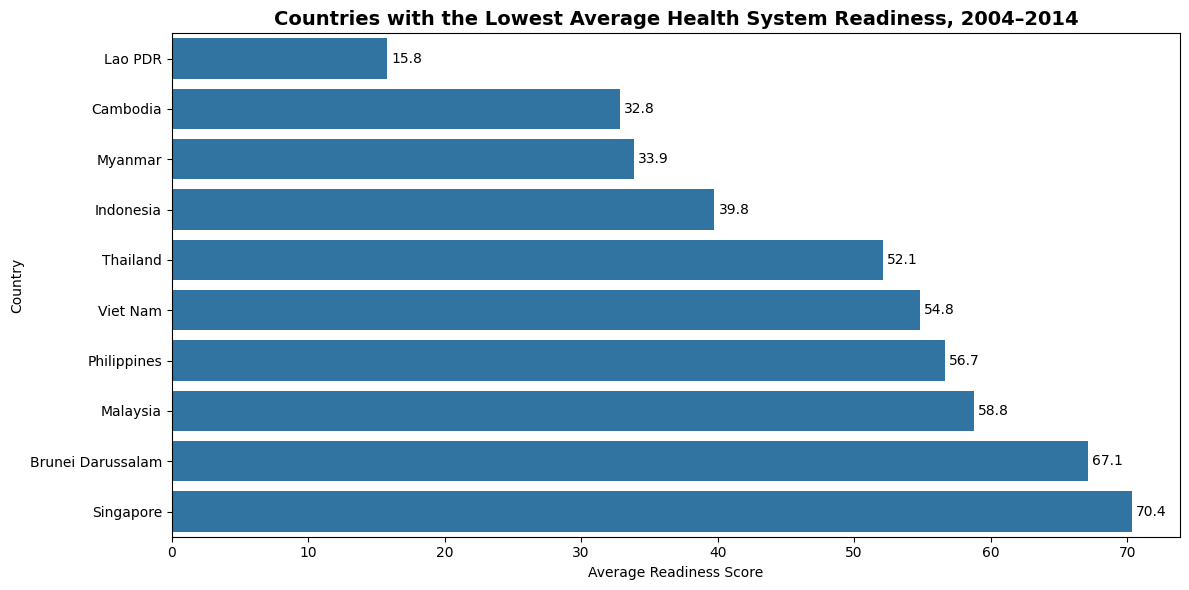

In [ ]:
# ------------------------------------------------------------
# 5. Show the 5 countries with the lowest readiness
# ------------------------------------------------------------

lowest_5_readiness = country_readiness.head(5)

lowest_5_readiness

# ------------------------------------------------------------
# 6. Visualize average readiness by country
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=country_readiness,
    x="avg_readiness_score",
    y="country"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.title(
    "Countries with the Lowest Average Health System Readiness, 2004–2014",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average Readiness Score")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

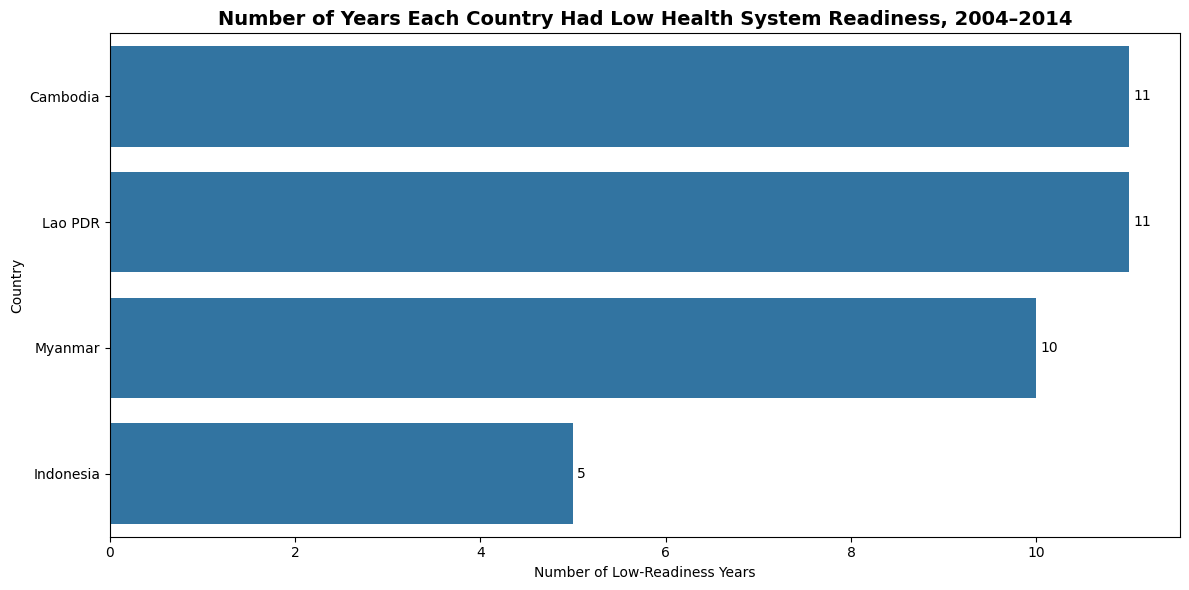

In [95]:
# ------------------------------------------------------------
# 7. Check readiness level distribution across all country-year observations
# ------------------------------------------------------------

readiness_distribution = health_df["readiness_level"].value_counts()

readiness_distribution
# ------------------------------------------------------------
# 8. Check readiness level percentage distribution
# ------------------------------------------------------------

readiness_distribution_percent = (
    health_df["readiness_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

readiness_distribution_percent

# ------------------------------------------------------------
# 9. Country-year observations with Low Readiness
# ------------------------------------------------------------

low_readiness_cases = (
    health_df[health_df["readiness_level"] == "Low"]
    .sort_values(["readiness_score"], ascending=True)
    [
        [
            "country",
            "year",
            "readiness_score",
            "readiness_level",
            "health_risk_score",
            "health_risk_level",
            "priority_category"
        ]
    ]
)

low_readiness_cases.head(20)

# ------------------------------------------------------------
# 10. Count how many times each country appeared as Low Readiness
# ------------------------------------------------------------

low_readiness_count = (
    health_df[health_df["readiness_level"] == "Low"]
    .groupby("country", as_index=False)
    .agg(low_readiness_years=("readiness_level", "count"))
    .sort_values("low_readiness_years", ascending=False)
)

low_readiness_count

# ------------------------------------------------------------
# 11. Visualize number of low-readiness years by country
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=low_readiness_count,
    x="low_readiness_years",
    y="country"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title(
    "Number of Years Each Country Had Low Health System Readiness, 2004–2014",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Low-Readiness Years")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

Which ASEAN countries had the weakest health system capacity between 2004 and 2014?

A low readiness score means the country may have weaknesses in:

Health expenditure
Immunization coverage
Physician availability
Nurses and midwives availability

This is important because a country can have high health risk, but the situation becomes more dangerous when its readiness is also low.

The analysis shows that countries with the lowest average Health System Readiness Scores had weaker capacity to prevent and respond to public health challenges between 2004 and 2014. 

Low readiness may reflect gaps in government health expenditure, immunization coverage, physician density, and nurses/midwives density. 

These countries may require targeted investment in health workforce expansion, immunization systems, and public health financing to strengthen their resilience against maternal, child health, and communicable disease risks.


3. Which countries fall into Emergency Priority?
Which countries are in the most dangerous position because they face high health burden and weak capacity to respond?

This directly supports the hackathon’s SDG 3 focus on improving healthcare decision-making, reducing health disparities, and strengthening healthcare response systems.

In [100]:
required_cols = [
    "country",
    "year",
    "health_risk_score",
    "health_risk_level",
    "readiness_score",
    "readiness_level",
    "priority_category"
]

missing_cols = [col for col in required_cols if col not in health_df.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are available.")

# 3. Filter Emergency Priority cases
# ------------------------------------------------------------

emergency_cases = health_df[
    health_df["priority_category"] == "Emergency Priority"
].copy()

emergency_cases = emergency_cases.sort_values(
    by=["health_risk_score", "readiness_score"],
    ascending=[False, True]
)

emergency_cases[
    [
        "country",
        "year",
        "health_risk_score",
        "health_risk_level",
        "readiness_score",
        "readiness_level",
        "priority_category"
    ]
].head(2)

All required columns are available.


,country,year,health_risk_score,health_risk_level,readiness_score,readiness_level,priority_category
92,Lao PDR,2004,77.993391,High,3.381166,Low,Emergency Priority
93,Lao PDR,2005,73.536930,High,12.897561,Low,Emergency Priority


Total Emergency Priority cases: 34


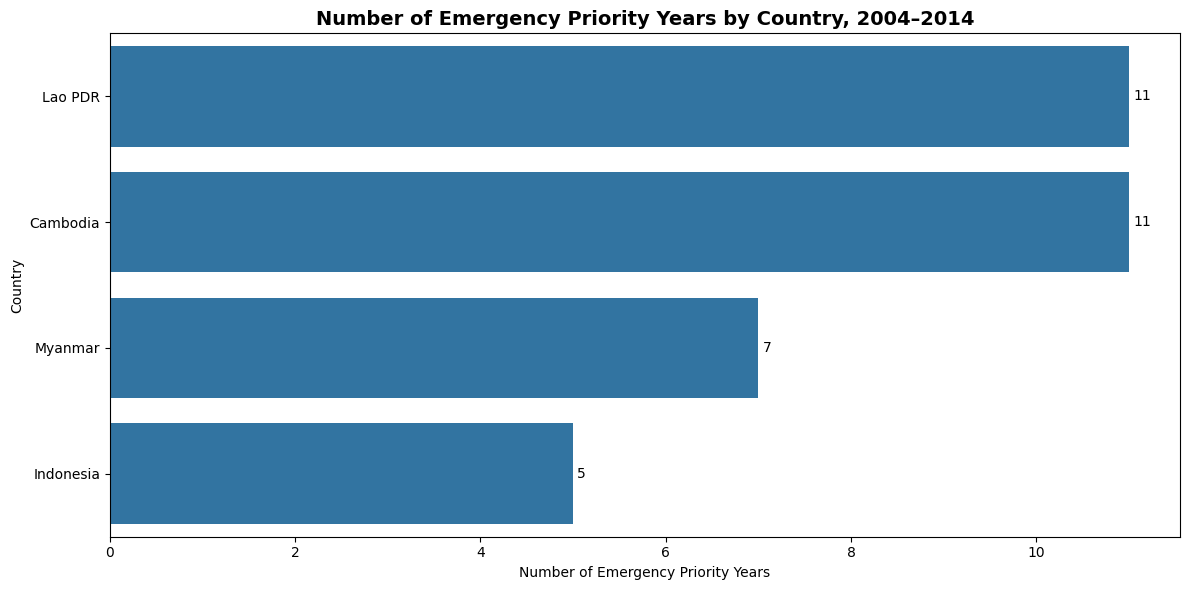

In [101]:
# ------------------------------------------------------------
# 4. Count total Emergency Priority observations
# ------------------------------------------------------------

total_emergency_cases = emergency_cases.shape[0]

print("Total Emergency Priority cases:", total_emergency_cases)
# ------------------------------------------------------------
# 5. Count Emergency Priority years by country
# ------------------------------------------------------------

emergency_by_country = (
    emergency_cases
    .groupby("country", as_index=False)
    .agg(
        emergency_years=("priority_category", "count"),
        avg_health_risk_score=("health_risk_score", "mean"),
        avg_readiness_score=("readiness_score", "mean"),
        first_emergency_year=("year", "min"),
        last_emergency_year=("year", "max")
    )
    .sort_values(
        by=["emergency_years", "avg_health_risk_score"],
        ascending=[False, False]
    )
)

emergency_by_country

# ------------------------------------------------------------
# 6. Visualize Emergency Priority years by country
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=emergency_by_country,
    x="emergency_years",
    y="country"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title(
    "Number of Emergency Priority Years by Country, 2004–2014",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Emergency Priority Years")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

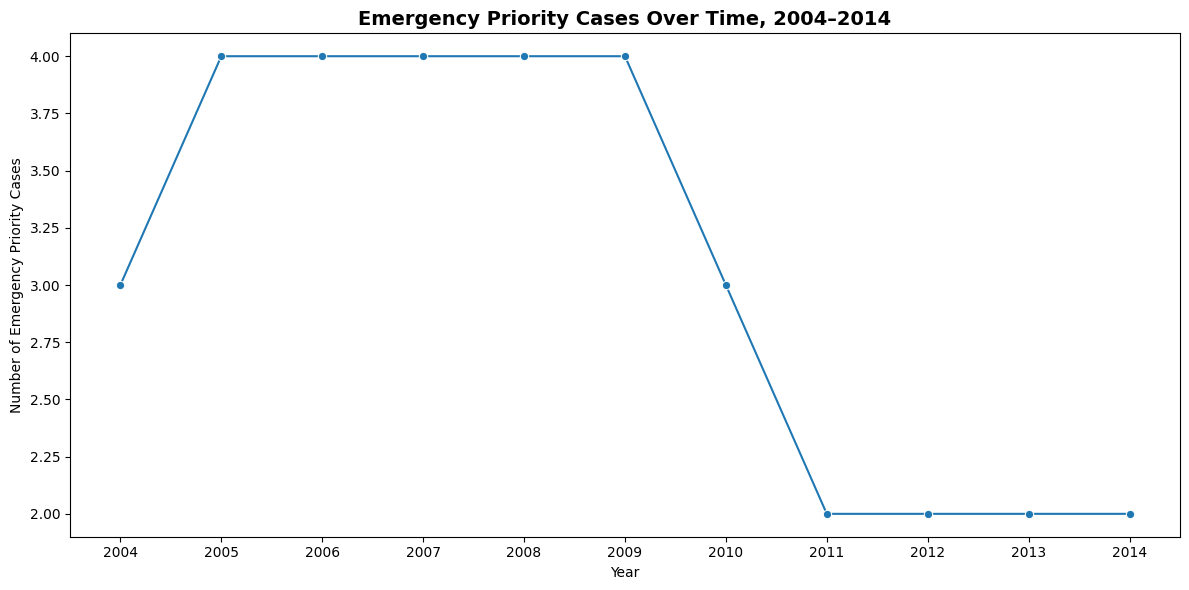

In [103]:
# ------------------------------------------------------------
# 7. Show Emergency Priority cases by year
# ------------------------------------------------------------

emergency_by_year = (
    emergency_cases
    .groupby("year", as_index=False)
    .agg(
        emergency_cases=("priority_category", "count")
    )
    .sort_values("year")
)

emergency_by_year

# ------------------------------------------------------------
# 8. Visualize Emergency Priority trend over time
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=emergency_by_year,
    x="year",
    y="emergency_cases",
    marker="o"
)

plt.title(
    "Emergency Priority Cases Over Time, 2004–2014",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Emergency Priority Cases")
plt.xticks(emergency_by_year["year"])
plt.tight_layout()
plt.show()

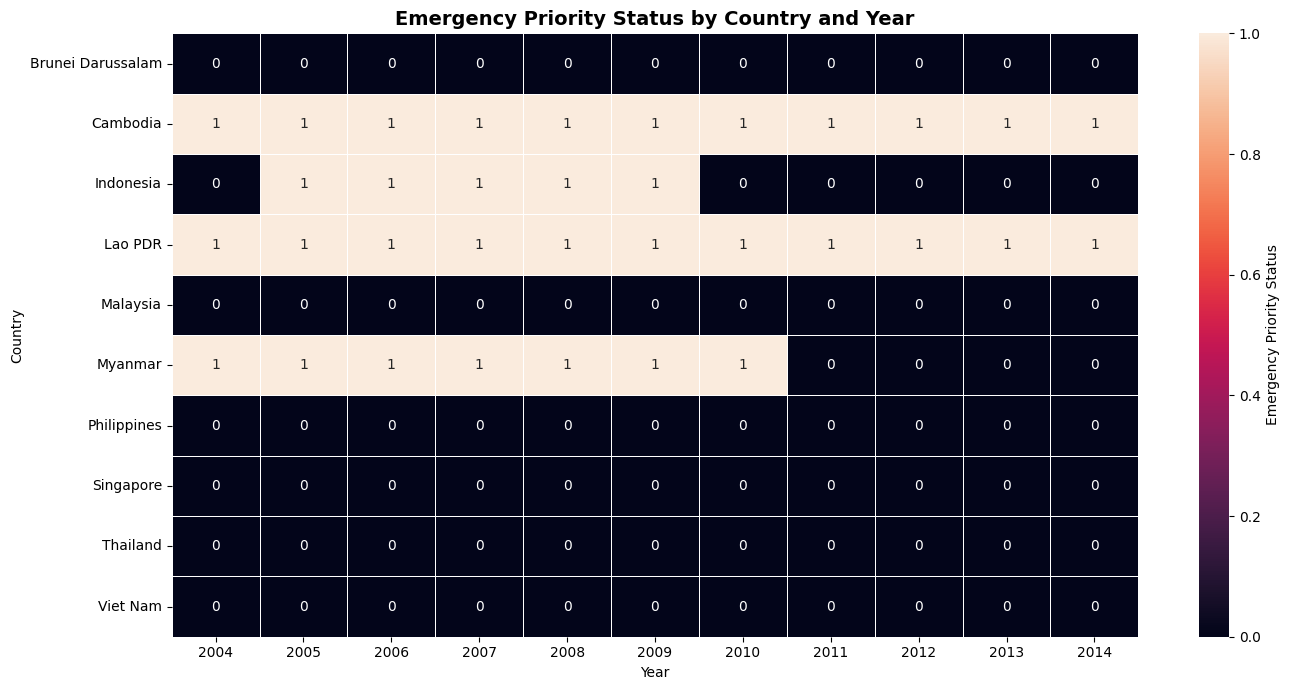

In [104]:
# ------------------------------------------------------------
# 9. Create a country-year heatmap of Emergency Priority
# ------------------------------------------------------------

health_df["is_emergency_priority"] = (
    health_df["priority_category"] == "Emergency Priority"
).astype(int)

emergency_heatmap_data = health_df.pivot_table(
    index="country",
    columns="year",
    values="is_emergency_priority",
    aggfunc="max"
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    emergency_heatmap_data,
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Emergency Priority Status"}
)

plt.title(
    "Emergency Priority Status by Country and Year",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [106]:
# ------------------------------------------------------------
# 10. Show the most severe Emergency Priority cases
# ------------------------------------------------------------

top_emergency_cases = emergency_cases[
    [
        "country",
        "year",
        "health_risk_score",
        "readiness_score",
        "health_risk_level",
        "readiness_level",
        "priority_category"
    ]
].head(1)

top_emergency_cases

,country,year,health_risk_score,readiness_score,health_risk_level,readiness_level,priority_category
92,Lao PDR,2004,77.993391,3.381166,High,Low,Emergency Priority


In [107]:
if emergency_cases.empty:
    print("No Emergency Priority cases found.")
    print("This means no country-year had both High Health Risk and Low Readiness under the current classification.")
else:
    print("Emergency Priority cases found:", emergency_cases.shape[0])

Emergency Priority cases found: 34


Emergency Priority countries are the most urgent intervention cases because they combine high public health risk with low health system readiness. 

These countries are not only experiencing severe health burden, but may also have weaker capacity to respond through health financing, immunization coverage, physician availability, and nurses/midwives density. 

This makes them important targets for urgent policy attention, resource allocation, and health system strengthening.

The Emergency Priority analysis identifies countries that recorded both High Health Risk and Low Health System Readiness. 

These countries represent the most urgent intervention group because they face severe health challenges while also having limited system capacity to respond. Countries appearing repeatedly in this category across multiple years should be treated as structural priority cases rather than temporary outliers.

All required columns are available.
Overall Health Risk Trend by Year


,year,avg_health_risk_score,median_health_risk_score,min_health_risk_score,max_health_risk_score
0,2004,30.756691,23.435961,3.532349,77.993391
1,2005,28.207277,21.032035,3.489045,73.536930
2,2006,27.191356,19.677029,3.246727,70.051266
3,2007,25.598294,18.358816,3.348020,64.285752
4,2008,23.184951,18.346968,3.430635,58.785936
5,2009,21.665222,17.789491,3.634098,53.512230
6,2010,19.616818,17.070202,3.578569,47.808725
7,2011,18.730637,16.390361,3.681318,46.210848
8,2012,17.642438,16.609132,3.703991,39.655783
9,2013,16.894129,15.578857,3.824048,37.381334


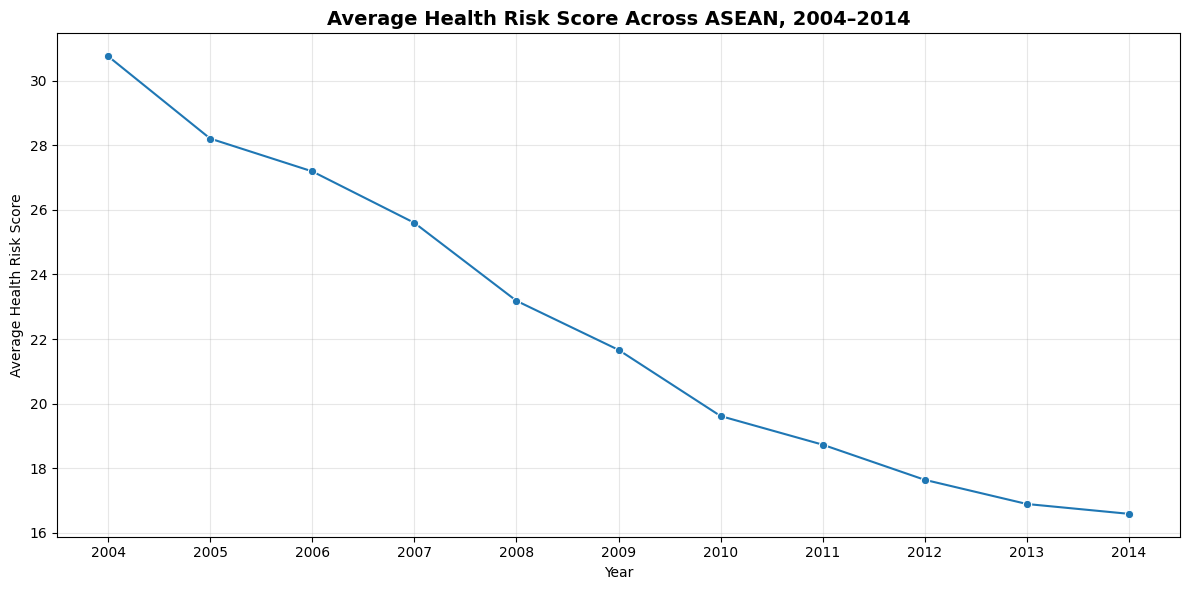

Country-Year Health Risk Trend


,country,year,avg_health_risk_score
0,Brunei Darussalam,2004,3.935064
1,Brunei Darussalam,2005,4.274500
2,Brunei Darussalam,2006,4.691469
3,Brunei Darussalam,2007,5.202188
4,Brunei Darussalam,2008,3.930905
5,Brunei Darussalam,2009,4.377258
6,Brunei Darussalam,2010,3.998506
7,Brunei Darussalam,2011,5.059386
8,Brunei Darussalam,2012,5.444140
9,Brunei Darussalam,2013,5.136557


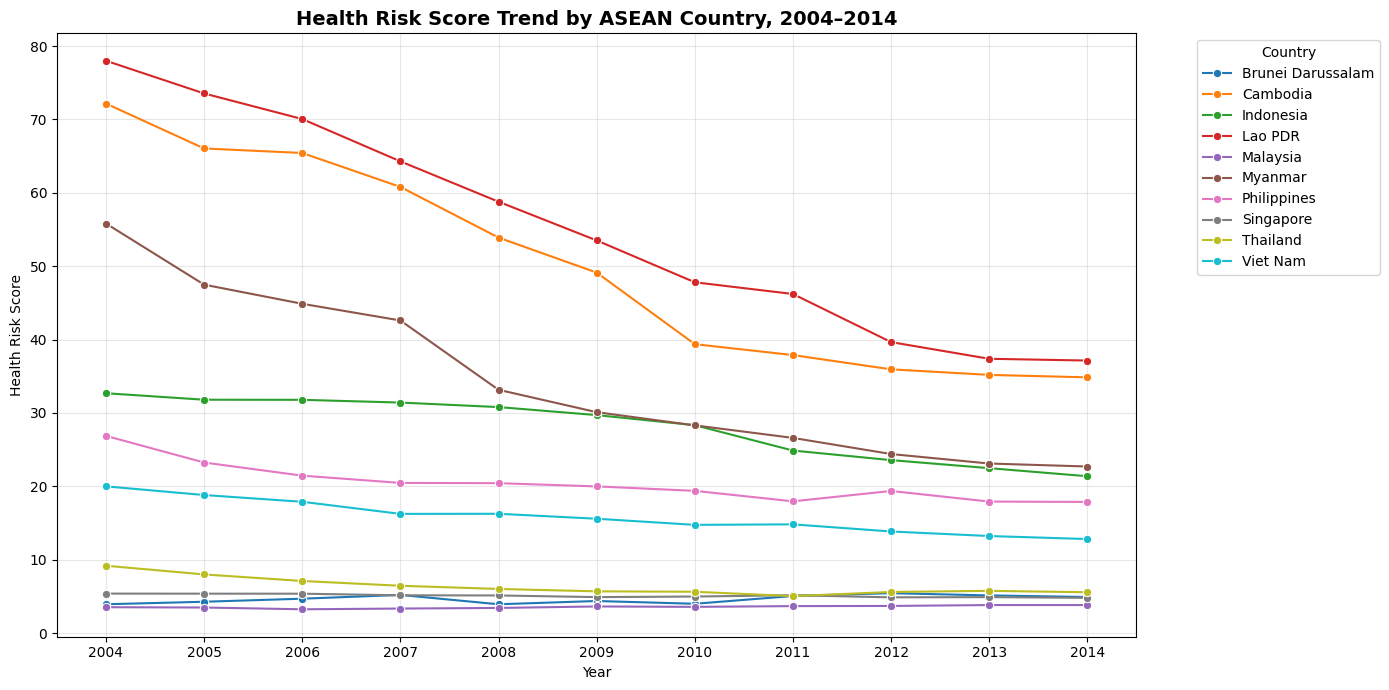

Health Risk Change from 2004 to 2014


,country,risk_2004,risk_2014,risk_change,percent_change,change_direction
3,Lao PDR,77.993391,37.142557,-40.850835,-52.38,Improved
1,Cambodia,72.161822,34.853070,-37.308753,-51.70,Improved
5,Myanmar,55.814412,22.704206,-33.110205,-59.32,Improved
2,Indonesia,32.688190,21.378491,-11.309699,-34.60,Improved
6,Philippines,26.875550,17.878286,-8.997264,-33.48,Improved
9,Viet Nam,19.996373,12.818207,-7.178166,-35.90,Improved
8,Thailand,9.184475,5.569113,-3.615362,-39.36,Improved
7,Singapore,5.385286,4.805894,-0.579391,-10.76,Improved
4,Malaysia,3.532349,3.824048,0.291699,8.26,Worsened
0,Brunei Darussalam,3.935064,4.921530,0.986467,25.07,Worsened


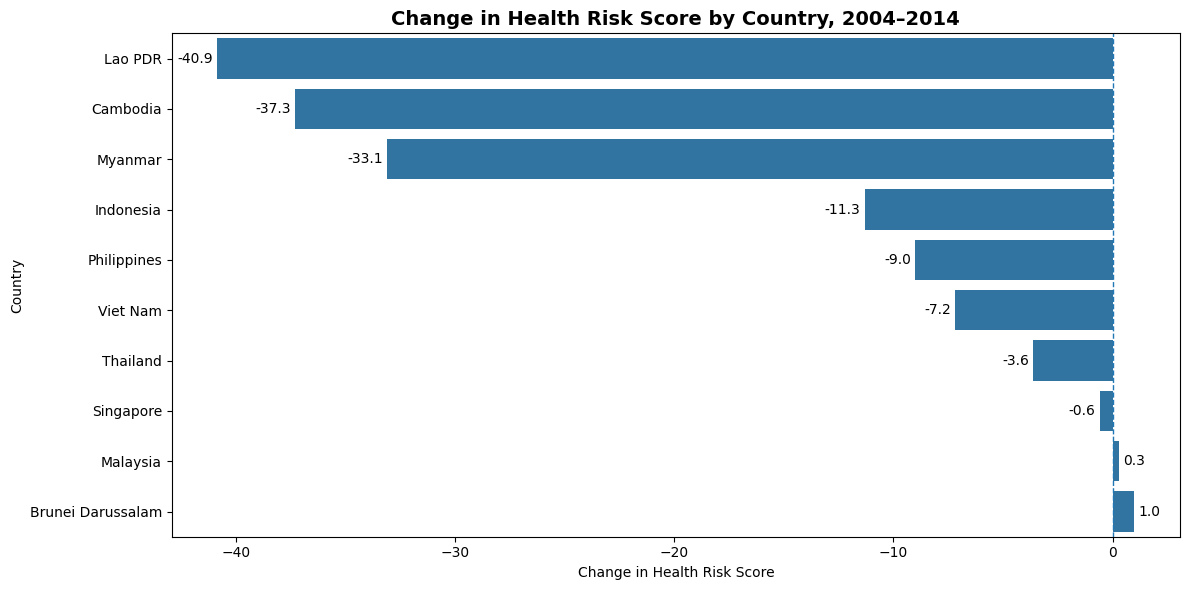

Top 5 Countries with the Biggest Improvement


,country,risk_2004,risk_2014,risk_change,percent_change,change_direction
3,Lao PDR,77.993391,37.142557,-40.850835,-52.38,Improved
1,Cambodia,72.161822,34.853070,-37.308753,-51.70,Improved
5,Myanmar,55.814412,22.704206,-33.110205,-59.32,Improved
2,Indonesia,32.688190,21.378491,-11.309699,-34.60,Improved
6,Philippines,26.875550,17.878286,-8.997264,-33.48,Improved


Top 5 Countries with the Biggest Worsening


,country,risk_2004,risk_2014,risk_change,percent_change,change_direction
0,Brunei Darussalam,3.935064,4.921530,0.986467,25.07,Worsened
4,Malaysia,3.532349,3.824048,0.291699,8.26,Worsened
7,Singapore,5.385286,4.805894,-0.579391,-10.76,Improved
8,Thailand,9.184475,5.569113,-3.615362,-39.36,Improved
9,Viet Nam,19.996373,12.818207,-7.178166,-35.90,Improved


Risk Level Distribution Over Time


,year,health_risk_level,count
0,2004,Low,3
1,2004,Medium,2
2,2004,High,5
3,2005,Low,3
4,2005,Medium,3
5,2005,High,4
6,2006,Low,3
7,2006,Medium,3
8,2006,High,4
9,2007,Low,3


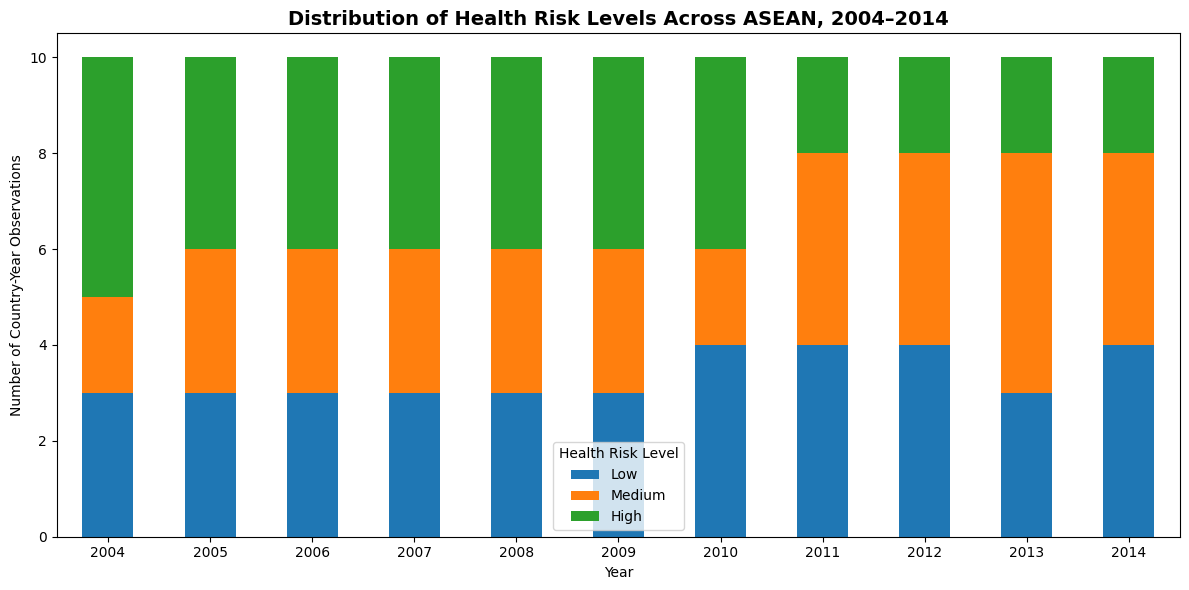

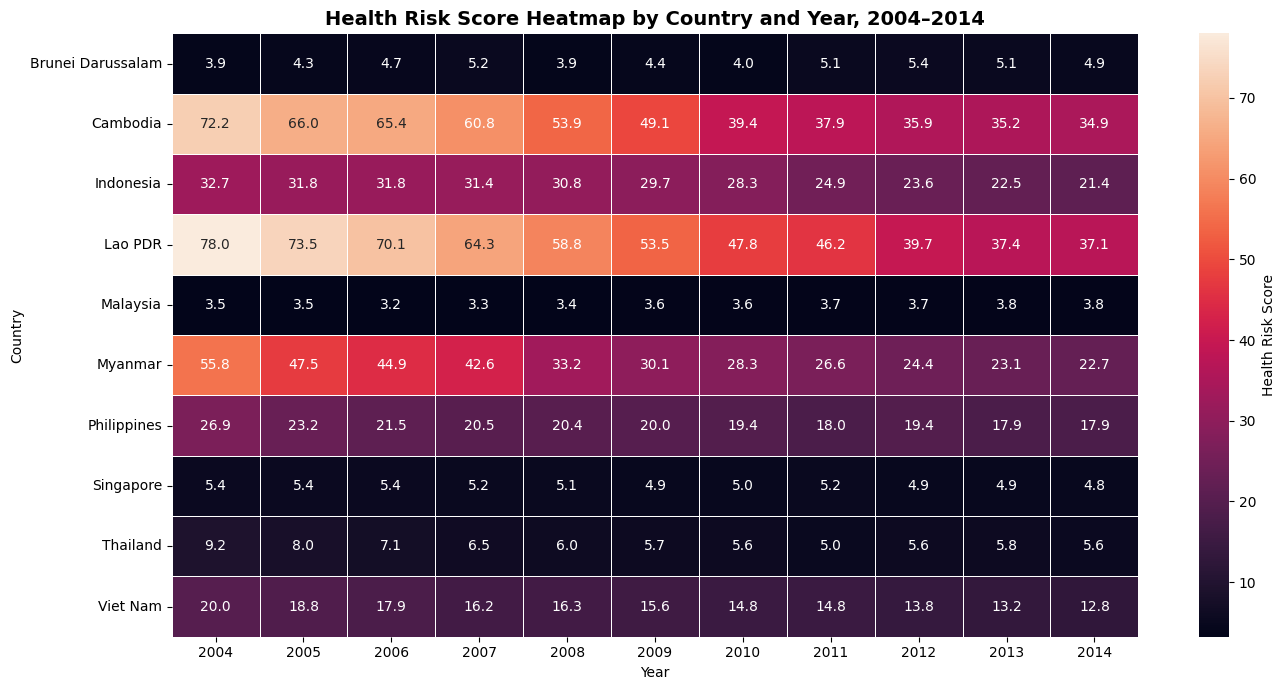

EDA 4 SUMMARY
Average Health Risk Score in 2004: 30.76
Average Health Risk Score in 2014: 16.59
Overall Change: -14.17
Overall Percent Change: -46.06%
Interpretation: Overall ASEAN health risk decreased between 2004 and 2014.


In [108]:
# ============================================================
# EDA 4: How has health risk changed from 2004 to 2014?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

# If health_df is already available in your notebook, leave this commented.
# If not, uncomment the line below:
# health_df = pd.read_csv("asean_health_risk_readiness_priority.csv")

# ------------------------------------------------------------
# 2. Confirm required columns
# ------------------------------------------------------------

required_cols = [
    "country",
    "year",
    "health_risk_score",
    "health_risk_level",
    "readiness_score",
    "readiness_level",
    "priority_category"
]

missing_cols = [col for col in required_cols if col not in health_df.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are available.")

# ------------------------------------------------------------
# 3. Prepare data
# ------------------------------------------------------------

health_df["year"] = health_df["year"].astype(int)

eda4_df = health_df[
    (health_df["year"] >= 2004) & 
    (health_df["year"] <= 2014)
].copy()

# ------------------------------------------------------------
# 4. Overall average health risk trend by year
# ------------------------------------------------------------

yearly_risk_trend = (
    eda4_df
    .groupby("year", as_index=False)
    .agg(
        avg_health_risk_score=("health_risk_score", "mean"),
        median_health_risk_score=("health_risk_score", "median"),
        min_health_risk_score=("health_risk_score", "min"),
        max_health_risk_score=("health_risk_score", "max")
    )
)

print("Overall Health Risk Trend by Year")
display(yearly_risk_trend)

# ------------------------------------------------------------
# 5. Plot overall average health risk trend
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_risk_trend,
    x="year",
    y="avg_health_risk_score",
    marker="o"
)

plt.title(
    "Average Health Risk Score Across ASEAN, 2004–2014",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Average Health Risk Score")
plt.xticks(yearly_risk_trend["year"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Health risk trend by country
# ------------------------------------------------------------

country_year_risk = (
    eda4_df
    .groupby(["country", "year"], as_index=False)
    .agg(avg_health_risk_score=("health_risk_score", "mean"))
)

print("Country-Year Health Risk Trend")
display(country_year_risk.head(20))

# ------------------------------------------------------------
# 7. Plot health risk trend by country
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=country_year_risk,
    x="year",
    y="avg_health_risk_score",
    hue="country",
    marker="o"
)

plt.title(
    "Health Risk Score Trend by ASEAN Country, 2004–2014",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Health Risk Score")
plt.xticks(sorted(country_year_risk["year"].unique()))
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Compare 2004 vs 2014 health risk for each country
# ------------------------------------------------------------

risk_2004_2014 = eda4_df[
    eda4_df["year"].isin([2004, 2014])
].pivot_table(
    index="country",
    columns="year",
    values="health_risk_score",
    aggfunc="mean"
).reset_index()

risk_2004_2014.columns.name = None

risk_2004_2014 = risk_2004_2014.rename(
    columns={
        2004: "risk_2004",
        2014: "risk_2014"
    }
)

risk_2004_2014["risk_change"] = (
    risk_2004_2014["risk_2014"] - risk_2004_2014["risk_2004"]
)

risk_2004_2014["percent_change"] = (
    (risk_2004_2014["risk_change"] / risk_2004_2014["risk_2004"]) * 100
).round(2)

def classify_change(change):
    if change < 0:
        return "Improved"
    elif change > 0:
        return "Worsened"
    else:
        return "No Change"

risk_2004_2014["change_direction"] = risk_2004_2014["risk_change"].apply(classify_change)

risk_2004_2014 = risk_2004_2014.sort_values("risk_change")

print("Health Risk Change from 2004 to 2014")
display(risk_2004_2014)

# ------------------------------------------------------------
# 9. Plot change in health risk from 2004 to 2014
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=risk_2004_2014,
    x="risk_change",
    y="country"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.axvline(0, linestyle="--", linewidth=1)

plt.title(
    "Change in Health Risk Score by Country, 2004–2014",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Change in Health Risk Score")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Countries with the biggest improvement
# ------------------------------------------------------------

most_improved = risk_2004_2014.sort_values("risk_change").head(5)

print("Top 5 Countries with the Biggest Improvement")
display(most_improved)

# ------------------------------------------------------------
# 11. Countries with the biggest worsening
# ------------------------------------------------------------

most_worsened = risk_2004_2014.sort_values("risk_change", ascending=False).head(5)

print("Top 5 Countries with the Biggest Worsening")
display(most_worsened)

# ------------------------------------------------------------
# 12. Risk level distribution over time
# ------------------------------------------------------------

risk_level_yearly = (
    eda4_df
    .groupby(["year", "health_risk_level"], as_index=False)
    .agg(count=("country", "count"))
)

print("Risk Level Distribution Over Time")
display(risk_level_yearly)

# ------------------------------------------------------------
# 13. Plot risk level distribution over time
# ------------------------------------------------------------

risk_level_pivot = risk_level_yearly.pivot(
    index="year",
    columns="health_risk_level",
    values="count"
).fillna(0)

risk_level_pivot = risk_level_pivot[["Low", "Medium", "High"]]

risk_level_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title(
    "Distribution of Health Risk Levels Across ASEAN, 2004–2014",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Country-Year Observations")
plt.xticks(rotation=0)
plt.legend(title="Health Risk Level")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 14. Heatmap of health risk score by country and year
# ------------------------------------------------------------

risk_heatmap_data = eda4_df.pivot_table(
    index="country",
    columns="year",
    values="health_risk_score",
    aggfunc="mean"
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    risk_heatmap_data,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Health Risk Score"}
)

plt.title(
    "Health Risk Score Heatmap by Country and Year, 2004–2014",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 15. Summary statistics for the trend
# ------------------------------------------------------------

start_avg = yearly_risk_trend.loc[
    yearly_risk_trend["year"] == 2004,
    "avg_health_risk_score"
].values[0]

end_avg = yearly_risk_trend.loc[
    yearly_risk_trend["year"] == 2014,
    "avg_health_risk_score"
].values[0]

overall_change = end_avg - start_avg
overall_percent_change = (overall_change / start_avg) * 100

print("==============================================")
print("EDA 4 SUMMARY")
print("==============================================")
print(f"Average Health Risk Score in 2004: {start_avg:.2f}")
print(f"Average Health Risk Score in 2014: {end_avg:.2f}")
print(f"Overall Change: {overall_change:.2f}")
print(f"Overall Percent Change: {overall_percent_change:.2f}%")

if overall_change < 0:
    print("Interpretation: Overall ASEAN health risk decreased between 2004 and 2014.")
elif overall_change > 0:
    print("Interpretation: Overall ASEAN health risk increased between 2004 and 2014.")
else:
    print("Interpretation: Overall ASEAN health risk remained unchanged between 2004 and 2014.")

The trend analysis examines how Health Risk Scores changed across ASEAN countries between 2004 and 2014. 

A declining score suggests improvement in public health burden, while an increasing score suggests worsening health risk. By comparing country-level scores in 2004 and 2014, the analysis identifies which countries experienced the strongest improvement and which countries may require closer policy attention. 

This helps determine whether health risk is improving across the region or whether certain countries remain persistently vulnerable.


All required columns are available.
Indicators Most Associated with Health Risk Score


,indicator,pearson_correlation,spearman_correlation,absolute_spearman_correlation
1,under_5_mortality_rate,0.978810,0.953645,0.953645
0,infant_mortality_rate,0.978544,0.947380,0.947380
2,maternal_mortality_rate,0.966259,0.894986,0.894986
5,undernourished_population,0.790804,0.851075,0.851075
7,dpt_immunization,-0.812368,-0.783933,0.783933
4,tb_prevalence,0.714027,0.778923,0.778923
9,nurses_midwives_density,-0.553762,-0.713756,0.713756
10,physicians_density,-0.651477,-0.699511,0.699511
8,measles_immunization,-0.737761,-0.655196,0.655196
3,malaria_prevalence,0.532172,0.435975,0.435975


Risk Indicators Associated with Health Risk Score


,indicator,pearson_correlation,spearman_correlation,absolute_spearman_correlation
1,under_5_mortality_rate,0.978810,0.953645,0.953645
0,infant_mortality_rate,0.978544,0.947380,0.947380
2,maternal_mortality_rate,0.966259,0.894986,0.894986
5,undernourished_population,0.790804,0.851075,0.851075
4,tb_prevalence,0.714027,0.778923,0.778923
3,malaria_prevalence,0.532172,0.435975,0.435975


Readiness Indicators Associated with Health Risk Score


,indicator,pearson_correlation,spearman_correlation,absolute_spearman_correlation
7,dpt_immunization,-0.812368,-0.783933,0.783933
9,nurses_midwives_density,-0.553762,-0.713756,0.713756
10,physicians_density,-0.651477,-0.699511,0.699511
8,measles_immunization,-0.737761,-0.655196,0.655196
6,government_health_expenditure,-0.369521,-0.426562,0.426562


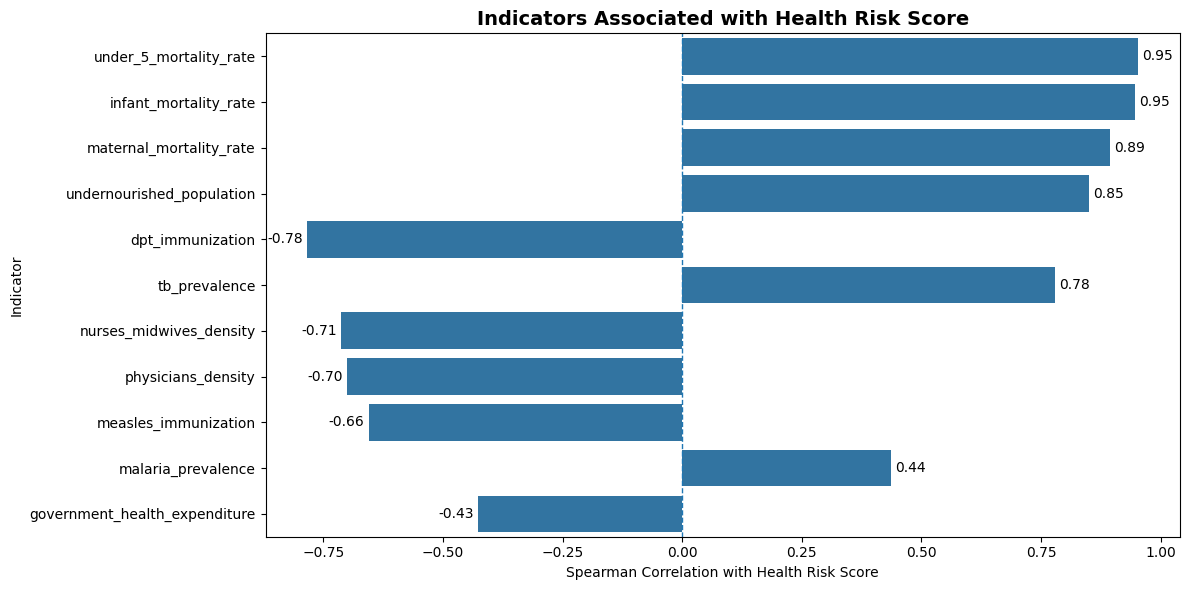

Average Indicator Values by Health Risk Level


,health_risk_level,infant_mortality_rate,under_5_mortality_rate,maternal_mortality_rate,malaria_prevalence,tb_prevalence,undernourished_population,government_health_expenditure,dpt_immunization,measles_immunization,nurses_midwives_density,physicians_density
0,Low,5.545946,7.104054,17.756757,21.977027,125.427027,8.340541,394.078378,96.883784,93.537838,4.574108,1.257108
1,Medium,18.852778,25.269444,103.208333,47.833333,231.158333,13.780556,470.708333,91.433333,90.077778,2.485639,0.816583
2,High,49.359459,61.654054,271.459459,198.651351,1025.689189,21.964865,143.286486,80.394595,75.405405,0.995932,0.270703


High Risk vs Non-High Risk Indicator Differences


,indicator,non_high_risk_avg,high_risk_avg,difference_high_minus_nonhigh,absolute_difference
4,tb_prevalence,177.568493,1025.689189,848.120696,848.120696
6,government_health_expenditure,431.868493,143.286486,-288.582007,288.582007
2,maternal_mortality_rate,59.897260,271.459459,211.562199,211.562199
3,malaria_prevalence,34.728082,198.651351,163.923269,163.923269
1,under_5_mortality_rate,16.062329,61.654054,45.591725,45.591725
0,infant_mortality_rate,12.108219,49.359459,37.251240,37.251240
8,measles_immunization,91.831507,75.405405,-16.426101,16.426101
7,dpt_immunization,94.195890,80.394595,-13.801296,13.801296
5,undernourished_population,11.023288,21.964865,10.941577,10.941577
9,nurses_midwives_density,3.544178,0.995932,-2.548246,2.548246


Standardized Difference Between High Risk and Non-High Risk Groups


,indicator,non_high_risk_avg_scaled,high_risk_avg_scaled,scaled_difference_high_minus_nonhigh,absolute_scaled_difference
1,under_5_mortality_rate,0.141709,0.621622,0.479913,0.479913
2,maternal_mortality_rate,0.126901,0.575126,0.448225,0.448225
0,infant_mortality_rate,0.122425,0.564839,0.442414,0.442414
10,physicians_density,0.507537,0.073718,-0.433819,0.433819
9,nurses_midwives_density,0.376900,0.035495,-0.341405,0.341405
5,undernourished_population,0.172587,0.486099,0.313512,0.313512
7,dpt_immunization,0.883918,0.607892,-0.276026,0.276026
8,measles_immunization,0.872367,0.615709,-0.256658,0.256658
3,malaria_prevalence,0.042093,0.247279,0.205186,0.205186
4,tb_prevalence,0.033672,0.233984,0.200312,0.200312


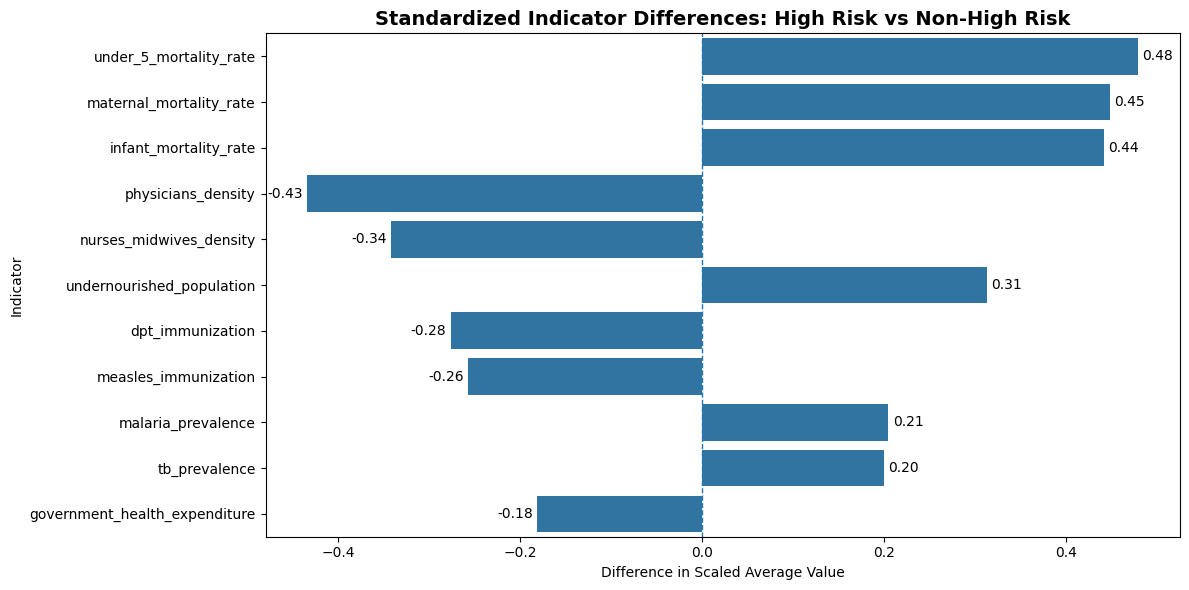

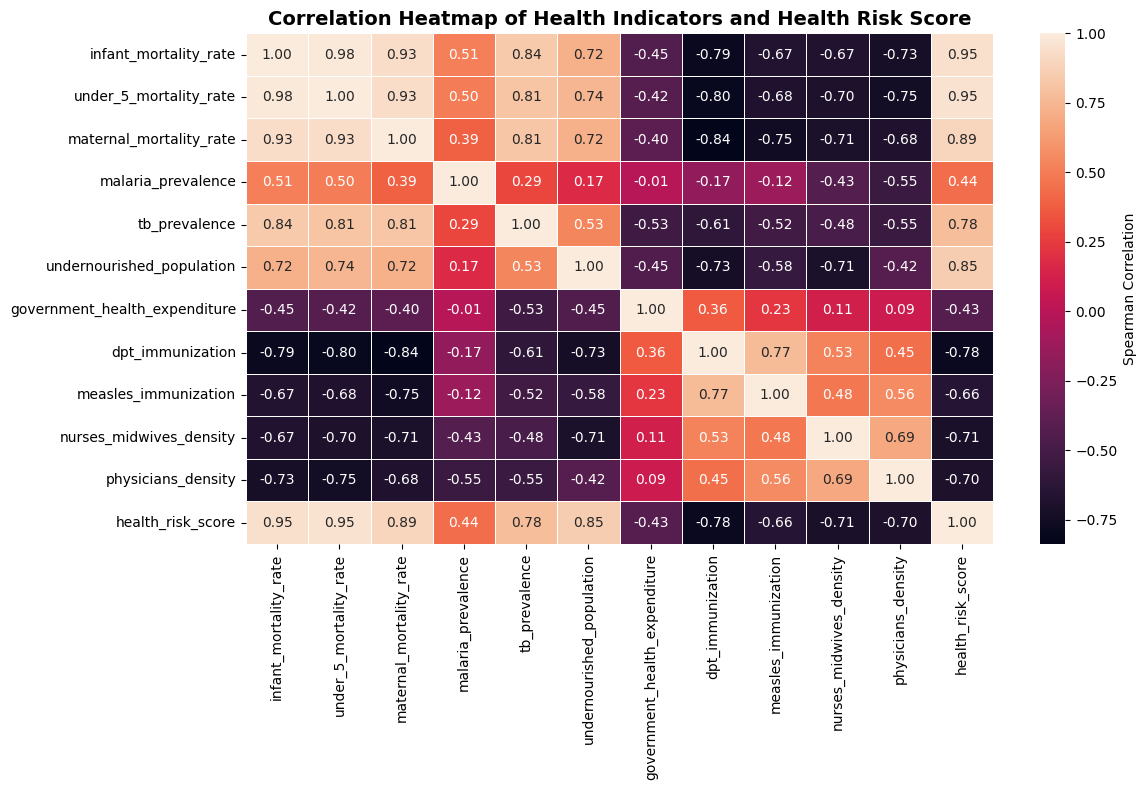

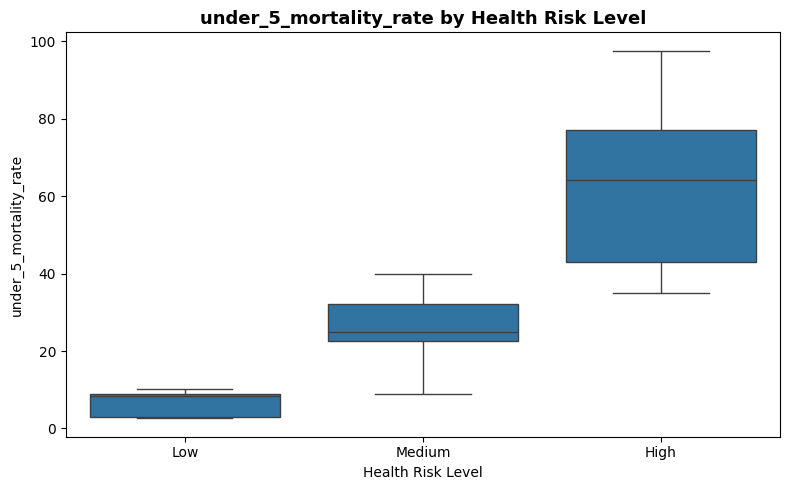

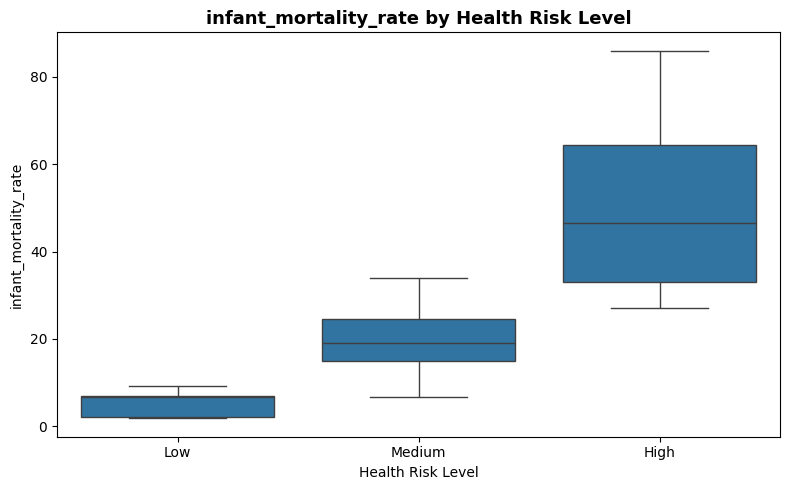

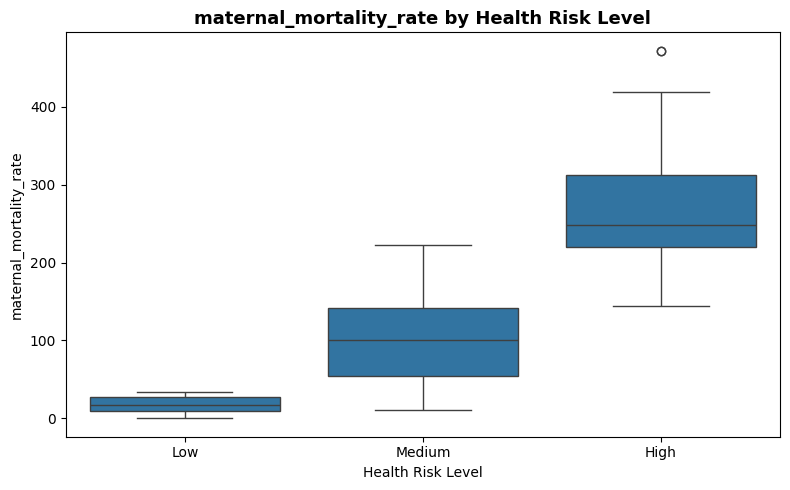

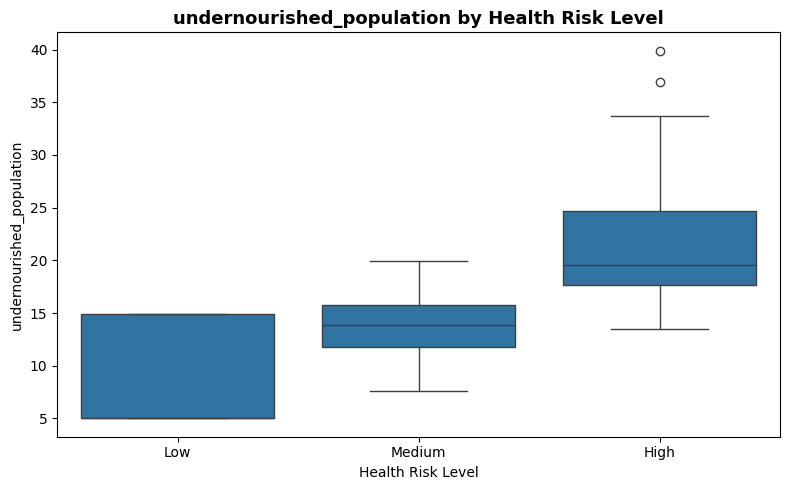

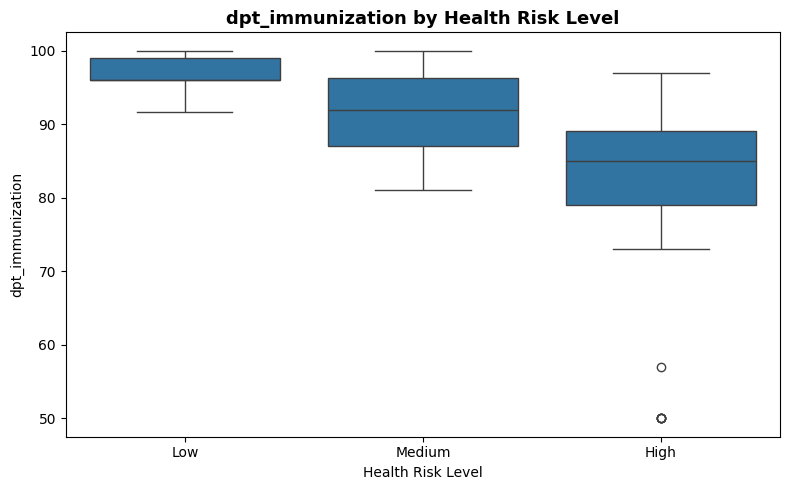

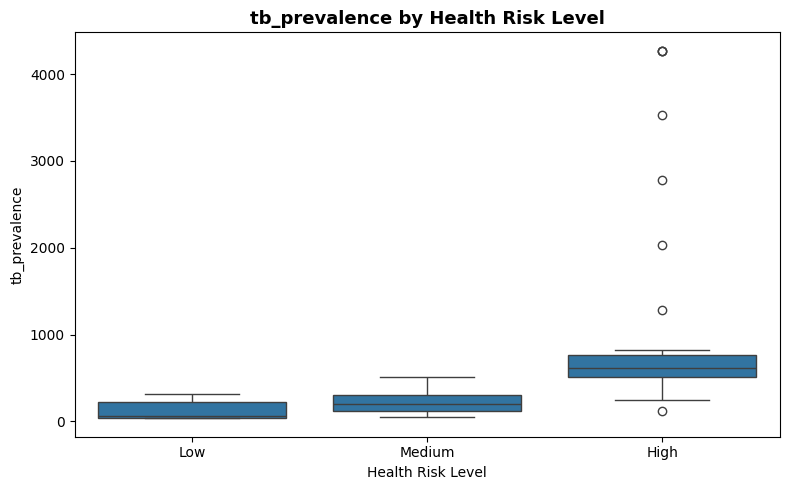

Final Indicator Association Table


,indicator,pearson_correlation,spearman_correlation,absolute_spearman_correlation,scaled_difference_high_minus_nonhigh,absolute_scaled_difference
0,under_5_mortality_rate,0.978810,0.953645,0.953645,0.479913,0.479913
1,infant_mortality_rate,0.978544,0.947380,0.947380,0.442414,0.442414
2,maternal_mortality_rate,0.966259,0.894986,0.894986,0.448225,0.448225
3,undernourished_population,0.790804,0.851075,0.851075,0.313512,0.313512
4,dpt_immunization,-0.812368,-0.783933,0.783933,-0.276026,0.276026
5,tb_prevalence,0.714027,0.778923,0.778923,0.200312,0.200312
6,nurses_midwives_density,-0.553762,-0.713756,0.713756,-0.341405,0.341405
7,physicians_density,-0.651477,-0.699511,0.699511,-0.433819,0.433819
8,measles_immunization,-0.737761,-0.655196,0.655196,-0.256658,0.256658
9,malaria_prevalence,0.532172,0.435975,0.435975,0.205186,0.205186


EDA 5 SUMMARY

Top 5 indicators most associated with Health Risk Score:


,indicator,pearson_correlation,spearman_correlation,absolute_spearman_correlation,scaled_difference_high_minus_nonhigh,absolute_scaled_difference
0,under_5_mortality_rate,0.978810,0.953645,0.953645,0.479913,0.479913
1,infant_mortality_rate,0.978544,0.947380,0.947380,0.442414,0.442414
2,maternal_mortality_rate,0.966259,0.894986,0.894986,0.448225,0.448225
3,undernourished_population,0.790804,0.851075,0.851075,0.313512,0.313512
4,dpt_immunization,-0.812368,-0.783933,0.783933,-0.276026,0.276026



Important note:
Risk indicators are expected to correlate strongly with the Health Risk Score because they were used to construct the score. Readiness indicators are used to understand whether weaker health system capacity is associated with higher risk.


In [109]:
# 2. Define indicator groups
# ------------------------------------------------------------

risk_indicators = [
    "infant_mortality_rate",
    "under_5_mortality_rate",
    "maternal_mortality_rate",
    "malaria_prevalence",
    "tb_prevalence",
    "undernourished_population"
]

readiness_indicators = [
    "government_health_expenditure",
    "dpt_immunization",
    "measles_immunization",
    "nurses_midwives_density",
    "physicians_density"
]

all_indicators = risk_indicators + readiness_indicators

required_cols = [
    "country",
    "year",
    "health_risk_score",
    "health_risk_level"
] + all_indicators

missing_cols = [col for col in required_cols if col not in health_df.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are available.")

# ------------------------------------------------------------
# 3. Create a working copy
# ------------------------------------------------------------

eda5_df = health_df.copy()

# Make sure year is numeric
eda5_df["year"] = eda5_df["year"].astype(int)

# Create a binary high-risk variable
# High = 1, Low/Medium = 0
eda5_df["is_high_risk"] = np.where(
    eda5_df["health_risk_level"] == "High",
    1,
    0
)

# ------------------------------------------------------------
# 4. Correlation with Health Risk Score
# ------------------------------------------------------------

correlation_results = []

for col in all_indicators:
    pearson_corr = eda5_df[col].corr(eda5_df["health_risk_score"], method="pearson")
    spearman_corr = eda5_df[col].corr(eda5_df["health_risk_score"], method="spearman")
    
    correlation_results.append({
        "indicator": col,
        "pearson_correlation": pearson_corr,
        "spearman_correlation": spearman_corr,
        "absolute_spearman_correlation": abs(spearman_corr)
    })

correlation_df = pd.DataFrame(correlation_results)

correlation_df = correlation_df.sort_values(
    "absolute_spearman_correlation",
    ascending=False
)

print("Indicators Most Associated with Health Risk Score")
display(correlation_df)

# ------------------------------------------------------------
# 5. Separate risk indicators and readiness indicators
# ------------------------------------------------------------

risk_indicator_correlation = correlation_df[
    correlation_df["indicator"].isin(risk_indicators)
].sort_values("absolute_spearman_correlation", ascending=False)

readiness_indicator_correlation = correlation_df[
    correlation_df["indicator"].isin(readiness_indicators)
].sort_values("absolute_spearman_correlation", ascending=False)

print("Risk Indicators Associated with Health Risk Score")
display(risk_indicator_correlation)

print("Readiness Indicators Associated with Health Risk Score")
display(readiness_indicator_correlation)

# ------------------------------------------------------------
# 6. Visualize indicator correlation with health risk score
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=correlation_df,
    x="spearman_correlation",
    y="indicator"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.axvline(0, linestyle="--", linewidth=1)

plt.title(
    "Indicators Associated with Health Risk Score",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Spearman Correlation with Health Risk Score")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Compare average indicator values by risk level
# ------------------------------------------------------------

risk_level_summary = (
    eda5_df
    .groupby("health_risk_level")[all_indicators]
    .mean()
    .reset_index()
)

# Reorder risk levels properly
risk_level_order = ["Low", "Medium", "High"]

risk_level_summary["health_risk_level"] = pd.Categorical(
    risk_level_summary["health_risk_level"],
    categories=risk_level_order,
    ordered=True
)

risk_level_summary = risk_level_summary.sort_values("health_risk_level")

print("Average Indicator Values by Health Risk Level")
display(risk_level_summary)

# ------------------------------------------------------------
# 8. High-risk vs non-high-risk comparison
# ------------------------------------------------------------

high_vs_nonhigh_summary = (
    eda5_df
    .groupby("is_high_risk")[all_indicators]
    .mean()
    .T
    .reset_index()
)

high_vs_nonhigh_summary.columns = [
    "indicator",
    "non_high_risk_avg",
    "high_risk_avg"
]

high_vs_nonhigh_summary["difference_high_minus_nonhigh"] = (
    high_vs_nonhigh_summary["high_risk_avg"] -
    high_vs_nonhigh_summary["non_high_risk_avg"]
)

high_vs_nonhigh_summary["absolute_difference"] = (
    high_vs_nonhigh_summary["difference_high_minus_nonhigh"].abs()
)

high_vs_nonhigh_summary = high_vs_nonhigh_summary.sort_values(
    "absolute_difference",
    ascending=False
)

print("High Risk vs Non-High Risk Indicator Differences")
display(high_vs_nonhigh_summary)

# ------------------------------------------------------------
# 9. Normalize indicators for fair comparison
# ------------------------------------------------------------

from sklearn.preprocessing import MinMaxScaler

scaled_df = eda5_df[["country", "year", "health_risk_level", "is_high_risk"]].copy()

scaler = MinMaxScaler()

scaled_indicator_cols = [col + "_scaled" for col in all_indicators]

scaled_df[scaled_indicator_cols] = scaler.fit_transform(
    eda5_df[all_indicators]
)

# ------------------------------------------------------------
# 10. Compare scaled average indicators for High vs Non-High Risk
# ------------------------------------------------------------

scaled_high_vs_nonhigh = (
    scaled_df
    .groupby("is_high_risk")[scaled_indicator_cols]
    .mean()
    .T
    .reset_index()
)

scaled_high_vs_nonhigh.columns = [
    "indicator",
    "non_high_risk_avg_scaled",
    "high_risk_avg_scaled"
]

scaled_high_vs_nonhigh["indicator"] = (
    scaled_high_vs_nonhigh["indicator"]
    .str.replace("_scaled", "", regex=False)
)

scaled_high_vs_nonhigh["scaled_difference_high_minus_nonhigh"] = (
    scaled_high_vs_nonhigh["high_risk_avg_scaled"] -
    scaled_high_vs_nonhigh["non_high_risk_avg_scaled"]
)

scaled_high_vs_nonhigh["absolute_scaled_difference"] = (
    scaled_high_vs_nonhigh["scaled_difference_high_minus_nonhigh"].abs()
)

scaled_high_vs_nonhigh = scaled_high_vs_nonhigh.sort_values(
    "absolute_scaled_difference",
    ascending=False
)

print("Standardized Difference Between High Risk and Non-High Risk Groups")
display(scaled_high_vs_nonhigh)

# ------------------------------------------------------------
# 11. Visualize standardized high-risk differences
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=scaled_high_vs_nonhigh,
    x="scaled_difference_high_minus_nonhigh",
    y="indicator"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.axvline(0, linestyle="--", linewidth=1)

plt.title(
    "Standardized Indicator Differences: High Risk vs Non-High Risk",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Difference in Scaled Average Value")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. Correlation heatmap
# ------------------------------------------------------------

corr_matrix = eda5_df[all_indicators + ["health_risk_score"]].corr(method="spearman")

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Spearman Correlation"}
)

plt.title(
    "Correlation Heatmap of Health Indicators and Health Risk Score",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. Boxplots for top associated indicators
# ------------------------------------------------------------

top_indicators = correlation_df.head(6)["indicator"].tolist()

for indicator in top_indicators:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=eda5_df,
        x="health_risk_level",
        y=indicator,
        order=["Low", "Medium", "High"]
    )
    
    plt.title(
        f"{indicator} by Health Risk Level",
        fontsize=13,
        fontweight="bold"
    )
    
    plt.xlabel("Health Risk Level")
    plt.ylabel(indicator)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 14. Final ranked table for interpretation
# ------------------------------------------------------------

final_association_table = correlation_df.merge(
    scaled_high_vs_nonhigh[
        [
            "indicator",
            "scaled_difference_high_minus_nonhigh",
            "absolute_scaled_difference"
        ]
    ],
    on="indicator",
    how="left"
)

final_association_table = final_association_table.sort_values(
    "absolute_spearman_correlation",
    ascending=False
)

print("Final Indicator Association Table")
display(final_association_table)

# ------------------------------------------------------------
# 15. Summary
# ------------------------------------------------------------

print("==============================================")
print("EDA 5 SUMMARY")
print("==============================================")

print("\nTop 5 indicators most associated with Health Risk Score:")
display(final_association_table.head(5))

print("\nImportant note:")
print(
    "Risk indicators are expected to correlate strongly with the Health Risk Score "
    "because they were used to construct the score. Readiness indicators are used "
    "to understand whether weaker health system capacity is associated with higher risk."
)

The indicator association analysis shows which variables move most closely with the Health Risk Score. 

Mortality, disease burden, and undernourishment indicators are expected to show strong positive relationships with health risk because they form the core components of the Health Risk Index. 
The analysis also examines health system readiness indicators such as immunization coverage, government health expenditure, physician density, and nurses/midwives density to understand whether stronger health system capacity is associated with lower public health risk.

This step helps explain the drivers of high-risk classification and supports the development of evidence-based policy recommendations. Countries classified as high risk should therefore be examined not only by their mortality and disease burden, but also by the strength or weakness of their health system readiness indicators.


6. Does low readiness appear connected to high risk?

All required columns are available.
Correlation Between Readiness Score and Health Risk Score
Pearson correlation: -0.885
Spearman correlation: -0.859


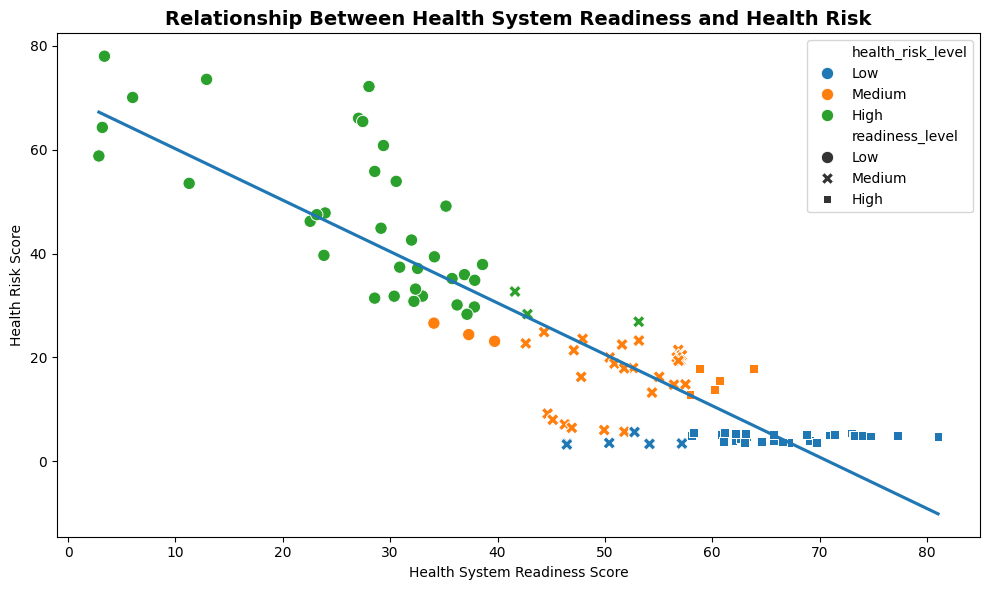

Average Health Risk by Readiness Level


,readiness_level,avg_health_risk_score,median_health_risk_score,min_health_risk_score,max_health_risk_score,observations
0,Low,45.109987,39.655783,23.110049,77.993391,37
1,Medium,15.621881,17.927964,3.246727,32.688190,36
2,High,6.197737,5.040725,3.578569,17.926041,37


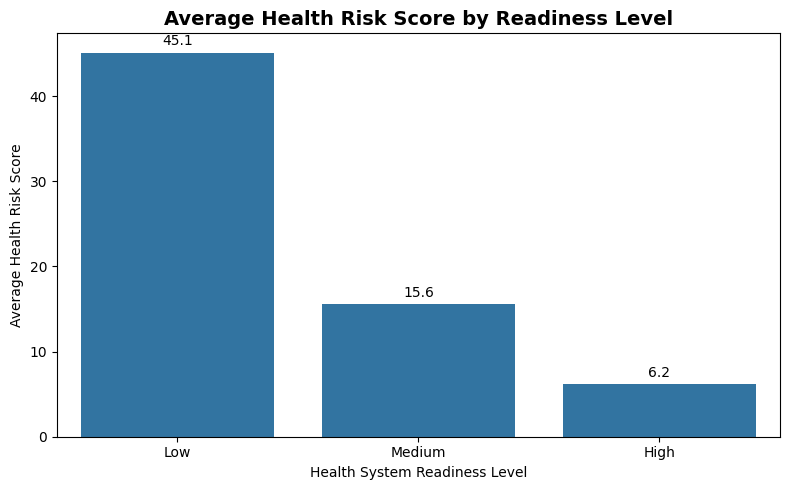

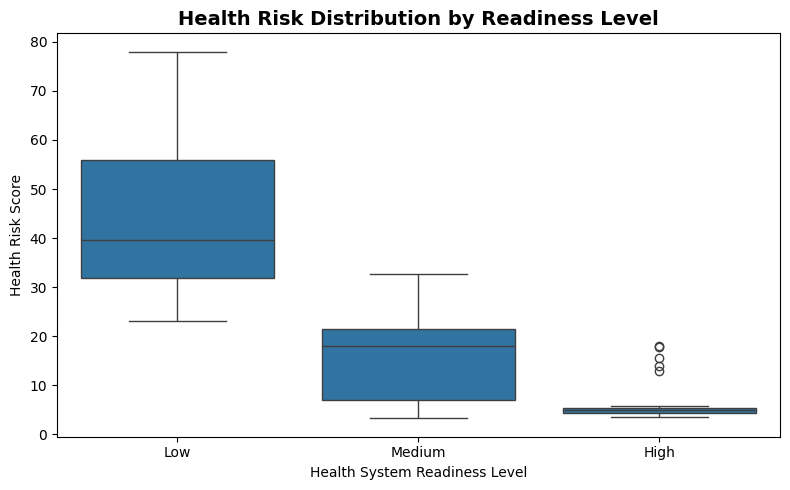

Readiness Level vs Health Risk Level


health_risk_level,Low,Medium,High
readiness_level,,,
Low,0,3,34
Medium,6,27,3
High,31,6,0


Readiness Level vs Health Risk Level (%)


health_risk_level,Low,Medium,High
readiness_level,,,
Low,0.00,8.11,91.89
Medium,16.67,75.00,8.33
High,83.78,16.22,0.00


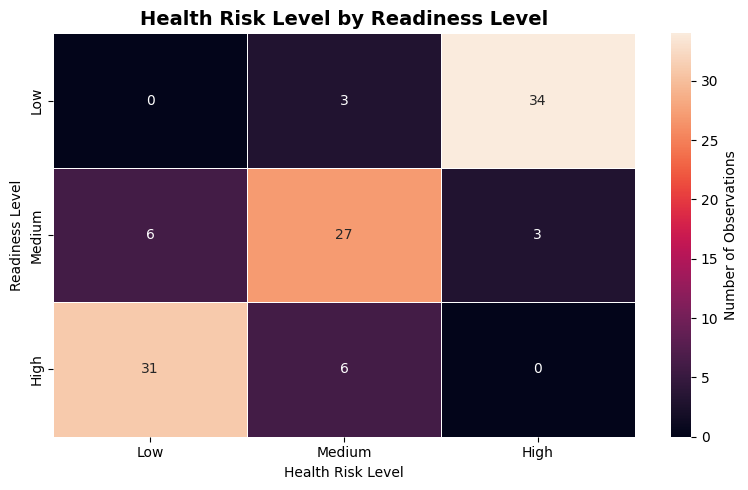

Priority Category Distribution


,priority_category,count
0,Emergency Priority,34
1,Stable / Resilient,31
2,Moderate Priority,27
3,Controlled Risk,6
4,Stable but Needs Support,6
5,High Priority,3
6,Preventive Priority,3


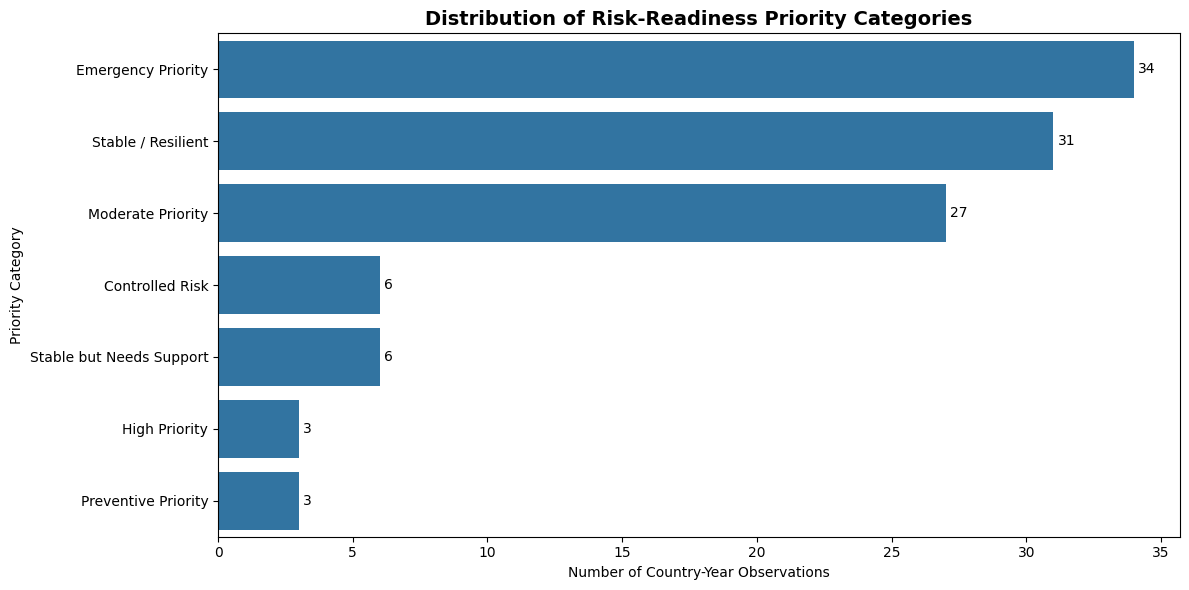

EDA 6 SUMMARY
There is a negative relationship between readiness and health risk. This suggests that higher readiness is generally associated with lower health risk.


,readiness_level,avg_health_risk_score,median_health_risk_score,min_health_risk_score,max_health_risk_score,observations
0,Low,45.109987,39.655783,23.110049,77.993391,37
1,Medium,15.621881,17.927964,3.246727,32.688190,36
2,High,6.197737,5.040725,3.578569,17.926041,37


health_risk_level,Low,Medium,High
readiness_level,,,
Low,0,3,34
Medium,6,27,3
High,31,6,0


In [110]:
# ============================================================
# EDA 6: Does low readiness appear connected to high risk?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

# If health_df is already available, leave this commented.
# health_df = pd.read_csv("asean_health_risk_readiness_priority.csv")

# ------------------------------------------------------------
# 2. Confirm required columns
# ------------------------------------------------------------

required_cols = [
    "country",
    "year",
    "health_risk_score",
    "health_risk_level",
    "readiness_score",
    "readiness_level",
    "priority_category"
]

missing_cols = [col for col in required_cols if col not in health_df.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are available.")

# ------------------------------------------------------------
# 3. Create ordered categories
# ------------------------------------------------------------

health_df["health_risk_level"] = pd.Categorical(
    health_df["health_risk_level"],
    categories=["Low", "Medium", "High"],
    ordered=True
)

health_df["readiness_level"] = pd.Categorical(
    health_df["readiness_level"],
    categories=["Low", "Medium", "High"],
    ordered=True
)

# ------------------------------------------------------------
# 4. Correlation between readiness score and health risk score
# ------------------------------------------------------------

pearson_corr = health_df["readiness_score"].corr(
    health_df["health_risk_score"],
    method="pearson"
)

spearman_corr = health_df["readiness_score"].corr(
    health_df["health_risk_score"],
    method="spearman"
)

print("Correlation Between Readiness Score and Health Risk Score")
print("Pearson correlation:", round(pearson_corr, 3))
print("Spearman correlation:", round(spearman_corr, 3))

# ------------------------------------------------------------
# 5. Scatter plot: readiness score vs health risk score
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=health_df,
    x="readiness_score",
    y="health_risk_score",
    hue="health_risk_level",
    style="readiness_level",
    s=80
)

sns.regplot(
    data=health_df,
    x="readiness_score",
    y="health_risk_score",
    scatter=False,
    ci=None
)

plt.title(
    "Relationship Between Health System Readiness and Health Risk",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Health System Readiness Score")
plt.ylabel("Health Risk Score")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Average health risk score by readiness level
# ------------------------------------------------------------

risk_by_readiness = (
    health_df
    .groupby("readiness_level", observed=False)
    .agg(
        avg_health_risk_score=("health_risk_score", "mean"),
        median_health_risk_score=("health_risk_score", "median"),
        min_health_risk_score=("health_risk_score", "min"),
        max_health_risk_score=("health_risk_score", "max"),
        observations=("country", "count")
    )
    .reset_index()
)

print("Average Health Risk by Readiness Level")
display(risk_by_readiness)

# ------------------------------------------------------------
# 7. Bar chart: average health risk by readiness level
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=risk_by_readiness,
    x="readiness_level",
    y="avg_health_risk_score",
    order=["Low", "Medium", "High"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.title(
    "Average Health Risk Score by Readiness Level",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Health System Readiness Level")
plt.ylabel("Average Health Risk Score")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Boxplot: health risk distribution by readiness level
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=health_df,
    x="readiness_level",
    y="health_risk_score",
    order=["Low", "Medium", "High"]
)

plt.title(
    "Health Risk Distribution by Readiness Level",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Health System Readiness Level")
plt.ylabel("Health Risk Score")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Cross-tab: readiness level vs health risk level
# ------------------------------------------------------------

risk_readiness_table = pd.crosstab(
    health_df["readiness_level"],
    health_df["health_risk_level"]
)

print("Readiness Level vs Health Risk Level")
display(risk_readiness_table)

# Percentage version
risk_readiness_percent = pd.crosstab(
    health_df["readiness_level"],
    health_df["health_risk_level"],
    normalize="index"
) * 100

risk_readiness_percent = risk_readiness_percent.round(2)

print("Readiness Level vs Health Risk Level (%)")
display(risk_readiness_percent)

# ------------------------------------------------------------
# 10. Heatmap of readiness-risk relationship
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.heatmap(
    risk_readiness_table,
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Number of Observations"}
)

plt.title(
    "Health Risk Level by Readiness Level",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Health Risk Level")
plt.ylabel("Readiness Level")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. Priority category distribution
# ------------------------------------------------------------

priority_distribution = (
    health_df["priority_category"]
    .value_counts()
    .reset_index()
)

priority_distribution.columns = ["priority_category", "count"]

print("Priority Category Distribution")
display(priority_distribution)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=priority_distribution,
    x="count",
    y="priority_category"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title(
    "Distribution of Risk-Readiness Priority Categories",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Country-Year Observations")
plt.ylabel("Priority Category")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. Summary statement
# ------------------------------------------------------------

print("==============================================")
print("EDA 6 SUMMARY")
print("==============================================")

if spearman_corr < 0:
    print(
        "There is a negative relationship between readiness and health risk. "
        "This suggests that higher readiness is generally associated with lower health risk."
    )
elif spearman_corr > 0:
    print(
        "There is a positive relationship between readiness and health risk. "
        "This suggests that higher readiness is not necessarily associated with lower health risk in this dataset."
    )
else:
    print(
        "There is no clear monotonic relationship between readiness and health risk."
    )

display(risk_by_readiness)
display(risk_readiness_table)

EDA 6 examines whether health system readiness is connected to health risk. 
If the correlation between readiness score and health risk score is negative, it suggests that countries with stronger health system capacity tend to have lower public health risk. 

The cross-tabulation between readiness level and health risk level helps validate the Risk–Readiness Matrix by showing whether low-readiness countries are more likely to appear in medium or high-risk categories.

7. Are our risk categories reasonable?

This EDA checks whether our Low, Medium, High categories make sense.

All required columns are available.
Health Risk Category Summary


,health_risk_level,min_score,q1_score,median_score,mean_score,q3_score,max_score,observations
0,Low,3.246727,3.824048,4.874925,4.545451,5.156152,5.636874,37
1,Medium,5.693815,13.694260,17.942855,16.937213,21.398319,26.601725,36
2,High,26.875550,32.688190,39.655783,45.482491,55.814412,77.993391,37


Health Risk Level Distribution


,health_risk_level,count,percent
0,Low,37,33.64
1,Medium,36,32.73
2,High,37,33.64


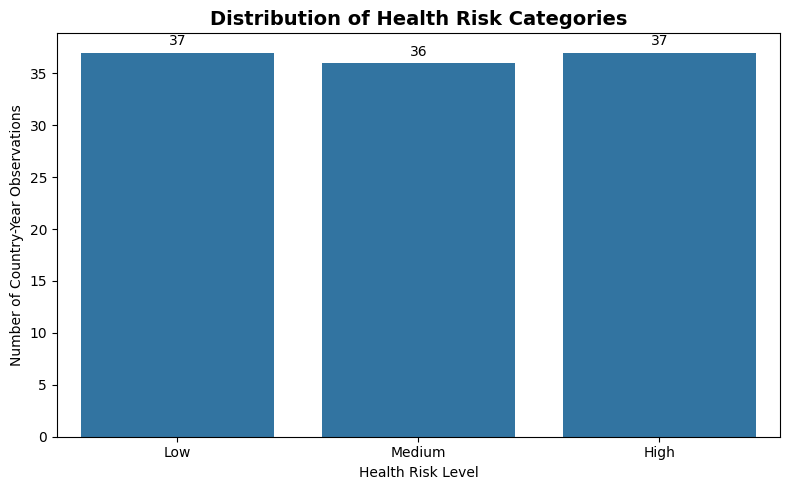

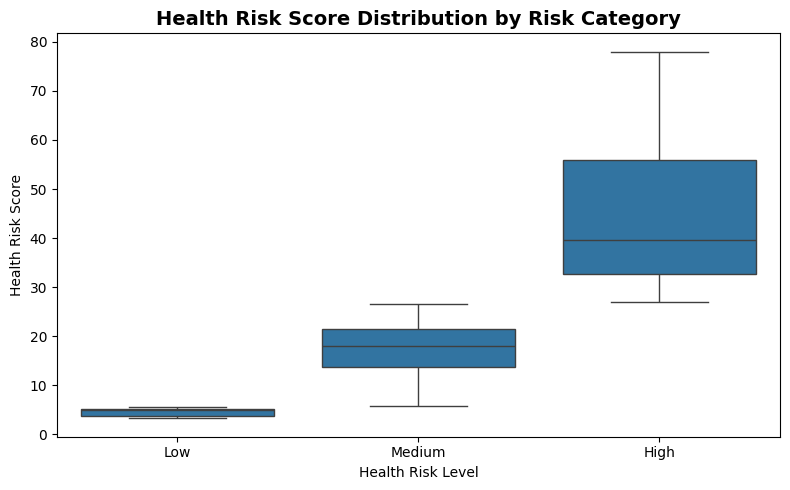

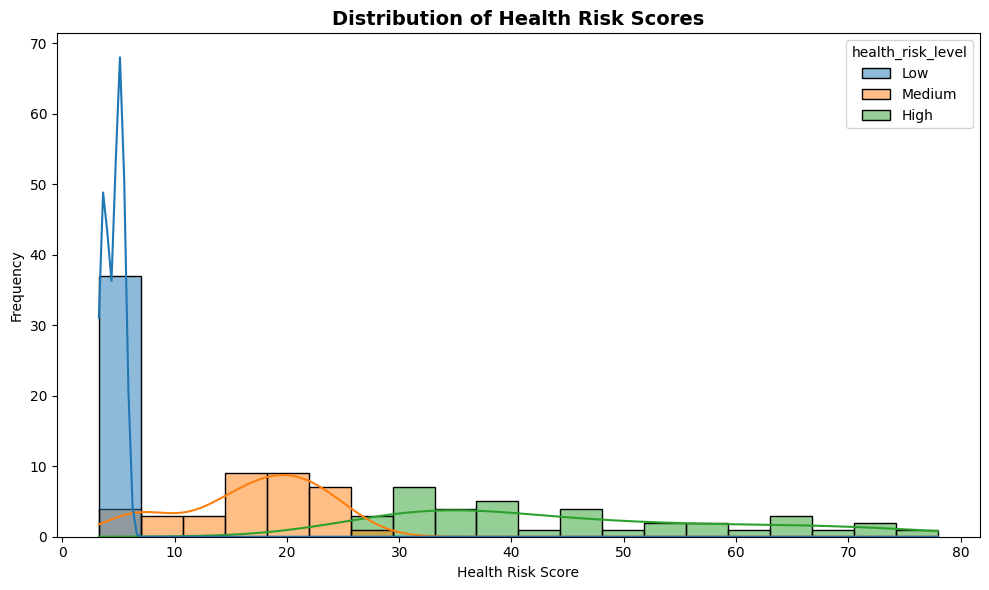

Risk Category Boundaries
Low maximum score: 5.64
Medium minimum score: 5.69
Medium maximum score: 26.6
High minimum score: 26.88
Mean Score Validation
Low mean: 4.55
Medium mean: 16.94
High mean: 45.48
Risk categories are logically ordered.
Country Distribution by Health Risk Category


health_risk_level,Low,Medium,High
country,,,
Brunei Darussalam,11,0,0
Cambodia,0,0,11
Indonesia,0,4,7
Lao PDR,0,0,11
Malaysia,11,0,0
Myanmar,0,4,7
Philippines,0,10,1
Singapore,11,0,0
Thailand,4,7,0


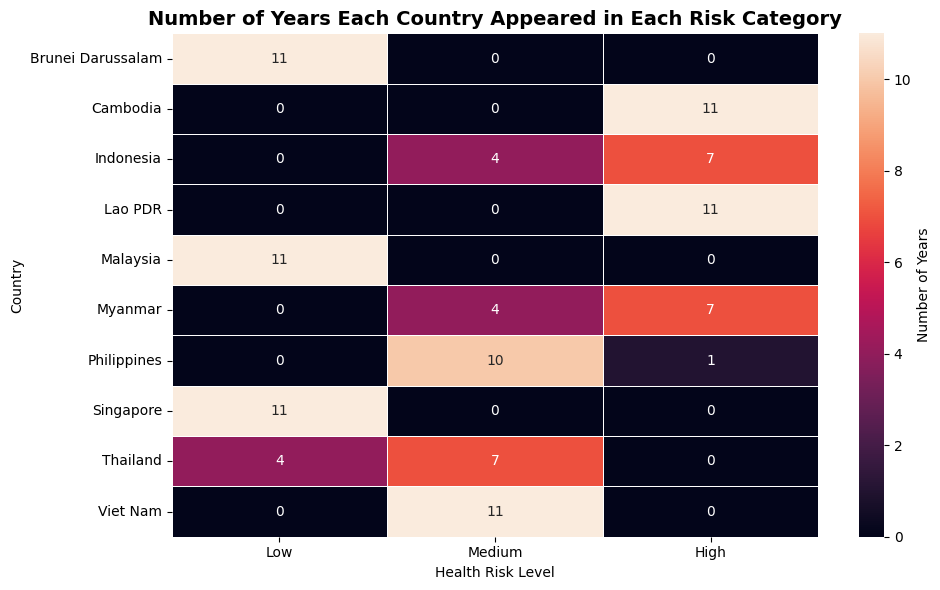

Country Risk Category Profile


,country,avg_health_risk_score,high_risk_years,medium_risk_years,low_risk_years,dominant_risk_category
3,Lao PDR,55.124068,11,0,0,High
1,Cambodia,50.064376,11,0,0,High
5,Myanmar,34.470392,7,4,0,High
2,Indonesia,28.077979,7,4,0,High
6,Philippines,20.454136,1,10,0,Medium
9,Viet Nam,15.843518,0,11,0,Medium
8,Thailand,6.369652,0,7,4,Medium
7,Singapore,5.096713,0,0,11,Low
0,Brunei Darussalam,4.633773,0,0,11,Low
4,Malaysia,3.572077,0,0,11,Low


EDA 7 SUMMARY
Risk category distribution:


,health_risk_level,count,percent
0,Low,37,33.64
1,Medium,36,32.73
2,High,37,33.64


The Low, Medium, and High risk categories are reasonable because their average Health Risk Scores increase in the expected order.
Because quantile-based classification was used, the categories are expected to be relatively balanced across the dataset.


In [111]:
# ============================================================
# EDA 7: Are our risk categories reasonable?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

# If health_df is already available, leave this commented.
# health_df = pd.read_csv("asean_health_risk_readiness_priority.csv")

# ------------------------------------------------------------
# 2. Confirm required columns
# ------------------------------------------------------------

required_cols = [
    "country",
    "year",
    "health_risk_score",
    "health_risk_level",
    "readiness_score",
    "readiness_level",
    "priority_category"
]

missing_cols = [col for col in required_cols if col not in health_df.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are available.")

# ------------------------------------------------------------
# 3. Set category order
# ------------------------------------------------------------

health_df["health_risk_level"] = pd.Categorical(
    health_df["health_risk_level"],
    categories=["Low", "Medium", "High"],
    ordered=True
)

health_df["readiness_level"] = pd.Categorical(
    health_df["readiness_level"],
    categories=["Low", "Medium", "High"],
    ordered=True
)

# ------------------------------------------------------------
# 4. Summary statistics by health risk level
# ------------------------------------------------------------

risk_category_summary = (
    health_df
    .groupby("health_risk_level", observed=False)
    .agg(
        min_score=("health_risk_score", "min"),
        q1_score=("health_risk_score", lambda x: x.quantile(0.25)),
        median_score=("health_risk_score", "median"),
        mean_score=("health_risk_score", "mean"),
        q3_score=("health_risk_score", lambda x: x.quantile(0.75)),
        max_score=("health_risk_score", "max"),
        observations=("country", "count")
    )
    .reset_index()
)

print("Health Risk Category Summary")
display(risk_category_summary)

# ------------------------------------------------------------
# 5. Risk level distribution
# ------------------------------------------------------------

risk_level_distribution = (
    health_df["health_risk_level"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
    .reset_index()
)

risk_level_distribution.columns = ["health_risk_level", "count"]

risk_level_distribution["percent"] = (
    risk_level_distribution["count"] / risk_level_distribution["count"].sum() * 100
).round(2)

print("Health Risk Level Distribution")
display(risk_level_distribution)

# ------------------------------------------------------------
# 6. Bar chart of risk level distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=risk_level_distribution,
    x="health_risk_level",
    y="count",
    order=["Low", "Medium", "High"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title(
    "Distribution of Health Risk Categories",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Health Risk Level")
plt.ylabel("Number of Country-Year Observations")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Boxplot of scores by risk level
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=health_df,
    x="health_risk_level",
    y="health_risk_score",
    order=["Low", "Medium", "High"]
)

plt.title(
    "Health Risk Score Distribution by Risk Category",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Health Risk Level")
plt.ylabel("Health Risk Score")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Histogram of health risk score
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    data=health_df,
    x="health_risk_score",
    hue="health_risk_level",
    bins=20,
    kde=True
)

plt.title(
    "Distribution of Health Risk Scores",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Health Risk Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Check score boundaries for each category
# ------------------------------------------------------------

low_max = health_df.loc[
    health_df["health_risk_level"] == "Low",
    "health_risk_score"
].max()

medium_min = health_df.loc[
    health_df["health_risk_level"] == "Medium",
    "health_risk_score"
].min()

medium_max = health_df.loc[
    health_df["health_risk_level"] == "Medium",
    "health_risk_score"
].max()

high_min = health_df.loc[
    health_df["health_risk_level"] == "High",
    "health_risk_score"
].min()

print("Risk Category Boundaries")
print("Low maximum score:", round(low_max, 2))
print("Medium minimum score:", round(medium_min, 2))
print("Medium maximum score:", round(medium_max, 2))
print("High minimum score:", round(high_min, 2))

# ------------------------------------------------------------
# 10. Validate ordering
# ------------------------------------------------------------

low_mean = health_df.loc[
    health_df["health_risk_level"] == "Low",
    "health_risk_score"
].mean()

medium_mean = health_df.loc[
    health_df["health_risk_level"] == "Medium",
    "health_risk_score"
].mean()

high_mean = health_df.loc[
    health_df["health_risk_level"] == "High",
    "health_risk_score"
].mean()

print("Mean Score Validation")
print("Low mean:", round(low_mean, 2))
print("Medium mean:", round(medium_mean, 2))
print("High mean:", round(high_mean, 2))

if low_mean < medium_mean < high_mean:
    print("Risk categories are logically ordered.")
else:
    print("Risk categories may need review.")

# ------------------------------------------------------------
# 11. Country distribution by risk category
# ------------------------------------------------------------

country_risk_category_count = pd.crosstab(
    health_df["country"],
    health_df["health_risk_level"]
)

country_risk_category_count = country_risk_category_count[
    ["Low", "Medium", "High"]
]

print("Country Distribution by Health Risk Category")
display(country_risk_category_count)

# ------------------------------------------------------------
# 12. Heatmap: country by risk category
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.heatmap(
    country_risk_category_count,
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Number of Years"}
)

plt.title(
    "Number of Years Each Country Appeared in Each Risk Category",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Health Risk Level")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. Average score by country and dominant risk category
# ------------------------------------------------------------

country_category_profile = (
    health_df
    .groupby("country")
    .agg(
        avg_health_risk_score=("health_risk_score", "mean"),
        high_risk_years=("health_risk_level", lambda x: (x == "High").sum()),
        medium_risk_years=("health_risk_level", lambda x: (x == "Medium").sum()),
        low_risk_years=("health_risk_level", lambda x: (x == "Low").sum())
    )
    .reset_index()
)

def dominant_category(row):
    counts = {
        "Low": row["low_risk_years"],
        "Medium": row["medium_risk_years"],
        "High": row["high_risk_years"]
    }
    return max(counts, key=counts.get)

country_category_profile["dominant_risk_category"] = country_category_profile.apply(
    dominant_category,
    axis=1
)

country_category_profile = country_category_profile.sort_values(
    "avg_health_risk_score",
    ascending=False
)

print("Country Risk Category Profile")
display(country_category_profile)

# ------------------------------------------------------------
# 14. Final validation summary
# ------------------------------------------------------------

print("==============================================")
print("EDA 7 SUMMARY")
print("==============================================")

print("Risk category distribution:")
display(risk_level_distribution)

if low_mean < medium_mean < high_mean:
    print(
        "The Low, Medium, and High risk categories are reasonable because "
        "their average Health Risk Scores increase in the expected order."
    )
else:
    print(
        "The categories may need adjustment because the average scores do not "
        "increase in the expected order."
    )

print(
    "Because quantile-based classification was used, the categories are expected "
    "to be relatively balanced across the dataset."
)

EDA 7 validates whether the Health Risk Categories are reasonable. 
The results show whether Low, Medium, and High categories are properly ordered by Health Risk Score and whether the distribution of observations across categories is balanced. Since the categories were created using quantile-based classification, the groups are expected to contain a similar number of country-year observations. 

This makes the classification useful for comparative analysis across ASEAN countries.

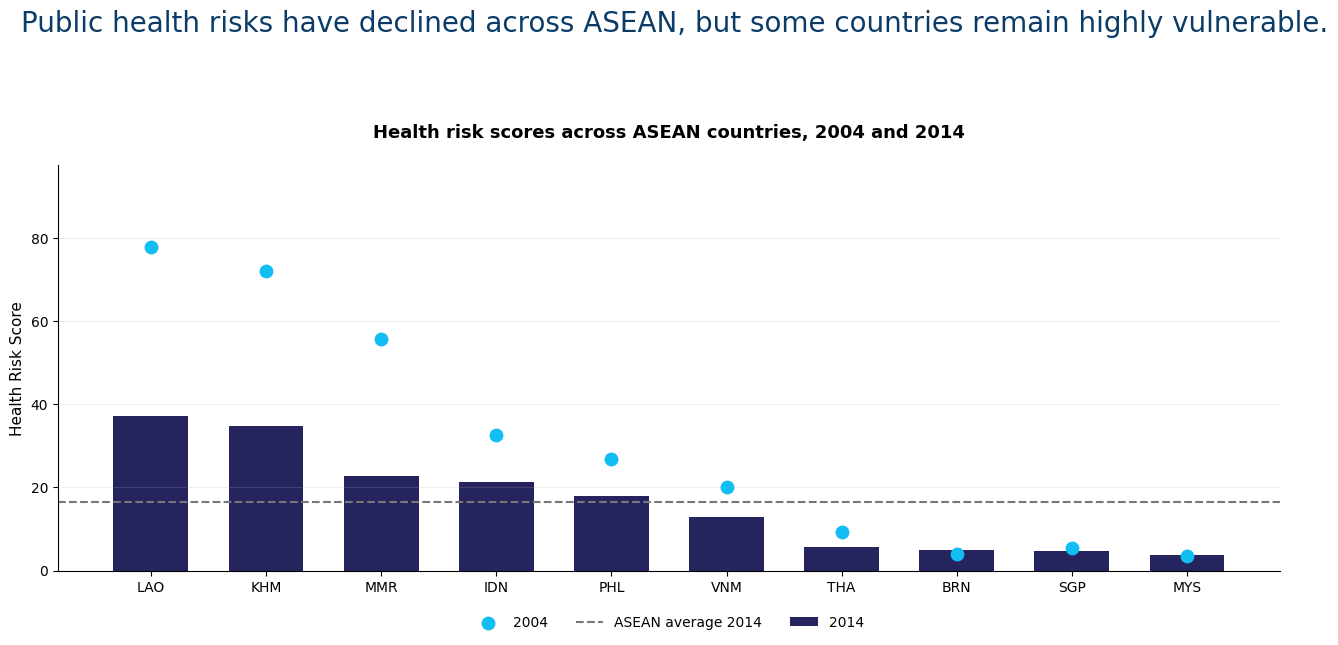

In [ ]:
# ------------------------------------------------------------
# 1. Make a copy
# ------------------------------------------------------------

chart_df = health_df.copy()

# Make sure year is integer
chart_df["year"] = chart_df["year"].astype(int)

# ------------------------------------------------------------
# 2. Keep only 2004 and 2014
# ------------------------------------------------------------

compare_years = chart_df[chart_df["year"].isin([2004, 2014])].copy()

# ------------------------------------------------------------
# 3. Pivot data: one row per country
# ------------------------------------------------------------

risk_compare = compare_years.pivot_table(
    index="country",
    columns="year",
    values="health_risk_score",
    aggfunc="mean"
).reset_index()

risk_compare.columns.name = None

risk_compare = risk_compare.rename(
    columns={
        2004: "risk_2004",
        2014: "risk_2014"
    }
)

# ------------------------------------------------------------
# 4. Optional: create country abbreviations
# ------------------------------------------------------------

country_codes = {
    "Brunei Darussalam": "BRN",
    "Cambodia": "KHM",
    "Indonesia": "IDN",
    "Lao PDR": "LAO",
    "Malaysia": "MYS",
    "Myanmar": "MMR",
    "Philippines": "PHL",
    "Singapore": "SGP",
    "Thailand": "THA",
    "Viet Nam": "VNM",
    "Vietnam": "VNM"
}

risk_compare["country_code"] = risk_compare["country"].map(country_codes)

# If any country was not mapped, use the first 3 letters
risk_compare["country_code"] = risk_compare["country_code"].fillna(
    risk_compare["country"].str[:3].str.upper()
)

# ------------------------------------------------------------
# 5. Sort countries by 2014 risk score
# ------------------------------------------------------------

risk_compare = risk_compare.sort_values("risk_2014", ascending=False)

# ------------------------------------------------------------
# 6. Calculate ASEAN average for 2014
# ------------------------------------------------------------

asean_avg_2014 = risk_compare["risk_2014"].mean()

# ------------------------------------------------------------
# 7. Dynamic headline logic
# ------------------------------------------------------------

avg_2004 = risk_compare["risk_2004"].mean()
avg_2014 = risk_compare["risk_2014"].mean()
change = avg_2014 - avg_2004

if change < 0:
    headline = "Public health risks have declined across ASEAN, but some countries remain highly vulnerable."
elif change > 0:
    headline = "Public health risks have increased across ASEAN, with several countries above the regional average."
else:
    headline = "Public health risks remained broadly stable across ASEAN, with clear country-level differences."

# ------------------------------------------------------------
# 8. Plot
# ------------------------------------------------------------

plt.figure(figsize=(13, 7))

x = np.arange(len(risk_compare))

bar_color = "#25245f"      # dark navy
dot_color = "#11bdf2"      # cyan blue
line_color = "#777777"     # grey

# 2014 bars
plt.bar(
    x,
    risk_compare["risk_2014"],
    color=bar_color,
    width=0.65,
    label="2014"
)

# 2004 dots
plt.scatter(
    x,
    risk_compare["risk_2004"],
    color=dot_color,
    s=80,
    zorder=3,
    label="2004"
)

# ASEAN average line for 2014
plt.axhline(
    asean_avg_2014,
    color=line_color,
    linestyle="--",
    linewidth=1.5,
    label="ASEAN average 2014"
)

# ------------------------------------------------------------
# 9. Add chart titles
# ------------------------------------------------------------

plt.suptitle(
    headline,
    fontsize=20,
    fontweight="normal",
    x=0.02,
    ha="left",
    color="#0b3c68"
)

plt.title(
    "Health risk scores across ASEAN countries, 2004 and 2014",
    fontsize=13,
    fontweight="bold",
    pad=20
)

# ------------------------------------------------------------
# 10. Format axes
# ------------------------------------------------------------

plt.xticks(
    x,
    risk_compare["country_code"],
    fontsize=10
)

plt.ylabel("Health Risk Score", fontsize=11)
plt.xlabel("")

plt.ylim(
    0,
    max(risk_compare["risk_2014"].max(), risk_compare["risk_2004"].max()) * 1.25
)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False
)

plt.grid(axis="y", alpha=0.2)

# Remove top and right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0.05, 1, 0.90])

# ------------------------------------------------------------
# 11. Save chart
# ------------------------------------------------------------

# plt.savefig(
#     "health_risk_scores_asean_2004_2014.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

This chart compares Health Risk Scores across ASEAN countries between 2004 and 2014. The bars represent each country’s Health Risk Score in 2014, while the blue dots represent the score in 2004. 

The dashed horizontal line shows the ASEAN average Health Risk Score in 2014. Countries with bars above the regional average may require closer policy attention, especially if their 2014 score remains high despite improvements from 2004.


All required columns are available.


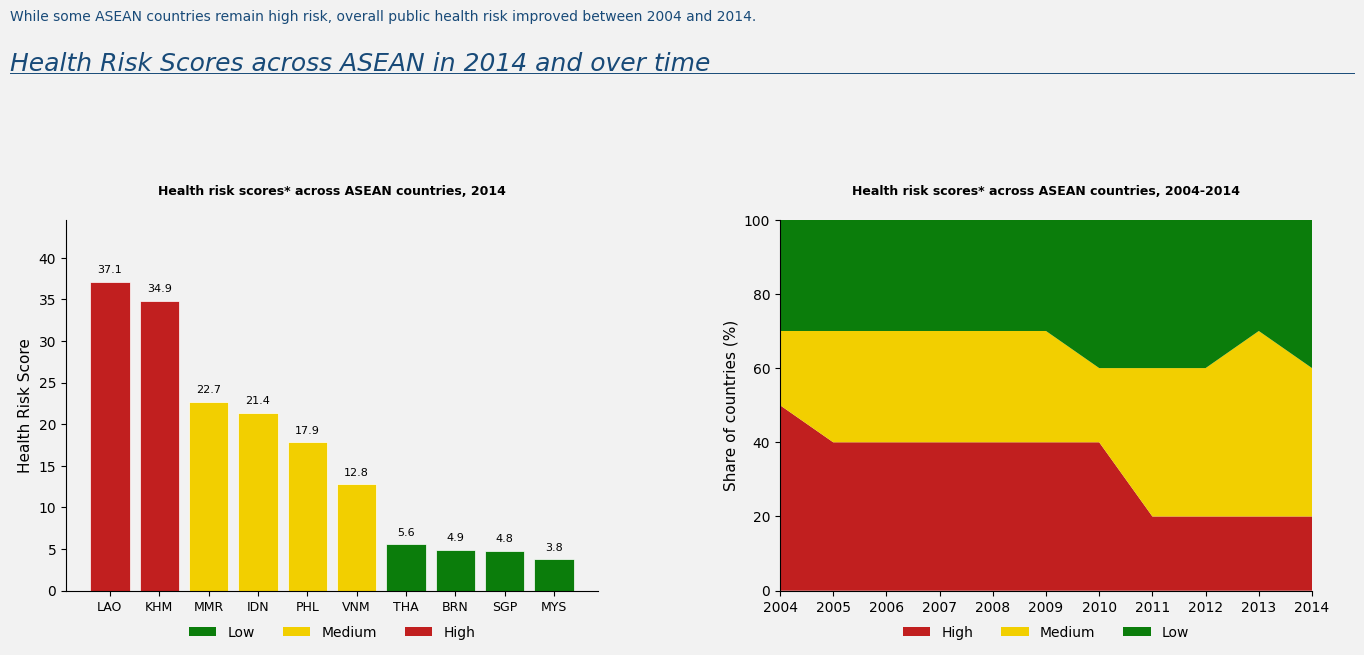

In [115]:
# ------------------------------------------------------------
required_cols = ["country", "year", "health_risk_score", "health_risk_level"]
missing_cols = [col for col in required_cols if col not in health_df.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are available.")

# Make a copy
df = health_df.copy()

# Ensure year is integer
df["year"] = df["year"].astype(int)

# Make sure risk levels are properly ordered
df["health_risk_level"] = pd.Categorical(
    df["health_risk_level"],
    categories=["Low", "Medium", "High"],
    ordered=True
)

# ------------------------------------------------------------
# 3. LEFT PANEL DATA: 2014 country scores
# ------------------------------------------------------------
df_2014 = df[df["year"] == 2014].copy()

# If multiple rows exist per country, average them
country_2014 = (
    df_2014
    .groupby("country", as_index=False)
    .agg(
        health_risk_score=("health_risk_score", "mean"),
        health_risk_level=("health_risk_level", lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0])
    )
)

# Sort descending by risk score
country_2014 = country_2014.sort_values("health_risk_score", ascending=False).reset_index(drop=True)

# Optional short country labels
country_code_map = {
    "Brunei Darussalam": "BRN",
    "Cambodia": "KHM",
    "Indonesia": "IDN",
    "Lao PDR": "LAO",
    "Malaysia": "MYS",
    "Myanmar": "MMR",
    "Philippines": "PHL",
    "Singapore": "SGP",
    "Thailand": "THA",
    "Viet Nam": "VNM",
    "Vietnam": "VNM"
}

country_2014["country_code"] = country_2014["country"].map(country_code_map)
country_2014["country_code"] = country_2014["country_code"].fillna(
    country_2014["country"].str[:3].str.upper()
)

# Color bars by risk level
risk_color_map = {
    "High": "#c11f1f",     # red
    "Medium": "#f2cf00",   # yellow/gold
    "Low": "#0b7d0b"       # green
}

country_2014["bar_color"] = country_2014["health_risk_level"].map(risk_color_map)

# ------------------------------------------------------------
# 4. RIGHT PANEL DATA: 2004-2014 share of countries by risk level
# ------------------------------------------------------------
risk_share = (
    df
    .groupby(["year", "health_risk_level"], observed=False)
    .size()
    .reset_index(name="count")
)

risk_share_pivot = risk_share.pivot(
    index="year",
    columns="health_risk_level",
    values="count"
).fillna(0)

# Make sure all categories exist
for col in ["Low", "Medium", "High"]:
    if col not in risk_share_pivot.columns:
        risk_share_pivot[col] = 0

risk_share_pivot = risk_share_pivot[["Low", "Medium", "High"]]

# Convert counts to percentages
risk_share_pct = risk_share_pivot.div(risk_share_pivot.sum(axis=1), axis=0) * 100

# ------------------------------------------------------------
# 5. Headline logic
# ------------------------------------------------------------
avg_2004 = df.loc[df["year"] == 2004, "health_risk_score"].mean()
avg_2014 = df.loc[df["year"] == 2014, "health_risk_score"].mean()

if avg_2014 < avg_2004:
    headline = "While some ASEAN countries remain high risk, overall public health risk improved between 2004 and 2014."
elif avg_2014 > avg_2004:
    headline = "Public health risks increased in several ASEAN countries between 2004 and 2014."
else:
    headline = "Public health risk remained broadly stable across ASEAN between 2004 and 2014."

subtitle = "Health Risk Scores across ASEAN in 2014 and over time"

# ------------------------------------------------------------
# 6. Create figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 7), facecolor="#f2f2f2")

# Header
fig.text(
    0.02, 0.95,
    headline,
    fontsize=10,
    color="#184a78",
    ha="left",
    va="top"
)

fig.text(
    0.02, 0.89,
    subtitle,
    fontsize=18,
    color="#184a78",
    ha="left",
    va="top",
    style="italic"
)

# Add a thin line under subtitle
fig.lines.append(
    plt.Line2D([0.02, 0.98], [0.86, 0.86], transform=fig.transFigure, color="#184a78", linewidth=0.7)
)

# Layout for the two charts
ax1 = fig.add_axes([0.06, 0.12, 0.38, 0.53], facecolor="#f2f2f2")
ax2 = fig.add_axes([0.57, 0.12, 0.38, 0.53], facecolor="#f2f2f2")

# ------------------------------------------------------------
# 7. LEFT PANEL: Bar chart for 2014
# ------------------------------------------------------------
x = np.arange(len(country_2014))

ax1.bar(
    x,
    country_2014["health_risk_score"],
    color=country_2014["bar_color"],
    edgecolor="white",
    linewidth=0.5
)

ax1.set_title(
    "Health risk scores* across ASEAN countries, 2014",
    fontsize=9,
    fontweight="bold",
    pad=18
)

ax1.set_ylabel("Health Risk Score", fontsize=11)
ax1.set_xlabel("")
ax1.set_xticks(x)
ax1.set_xticklabels(country_2014["country_code"], fontsize=9)
ax1.set_ylim(0, country_2014["health_risk_score"].max() * 1.2)

# Optional labels above bars
for i, val in enumerate(country_2014["health_risk_score"]):
    ax1.text(i, val + 0.8, f"{val:.1f}", ha="center", va="bottom", fontsize=8)

# Style
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(False)

# Legend for bar colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#0b7d0b", label="Low"),
    Patch(facecolor="#f2cf00", label="Medium"),
    Patch(facecolor="#c11f1f", label="High")
]
ax1.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.06),
    ncol=3,
    frameon=False
)

# ------------------------------------------------------------
# 8. RIGHT PANEL: Stacked area chart 2004-2014
# ------------------------------------------------------------
years = risk_share_pct.index.values
low_vals = risk_share_pct["Low"].values
med_vals = risk_share_pct["Medium"].values
high_vals = risk_share_pct["High"].values

ax2.stackplot(
    years,
    high_vals,
    med_vals,
    low_vals,
    colors=["#c11f1f", "#f2cf00", "#0b7d0b"]
)

ax2.set_title(
    "Health risk scores* across ASEAN countries, 2004-2014",
    fontsize=9,
    fontweight="bold",
    pad=18
)

ax2.set_ylabel("Share of countries (%)", fontsize=11)
ax2.set_xlabel("")
ax2.set_xlim(years.min(), years.max())
ax2.set_ylim(0, 100)
ax2.set_xticks(years)
ax2.set_yticks([0, 20, 40, 60, 80, 100])

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(False)

# Legend
ax2.legend(
    ["High", "Medium", "Low"],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.06),
    ncol=3,
    frameon=False
)


plt.show()

Machine Learning
Predict next year’s health risk level for each ASEAN country.

Create the next-year target.
Select features.
Split data into train and test.
Train baseline model.
Train Random Forest model.
Evaluate accuracy, precision, recall, F1-score, and confusion matrix.
Use feature importance to explain what drives predicted risk.
Convert model output into policy recommendation.

In [119]:
# Make a copy
ml_df = health_df.copy()

# Ensure year is integer
ml_df["year"] = ml_df["year"].astype(int)

# Sort properly before shifting
ml_df = ml_df.sort_values(["country", "year"]).reset_index(drop=True)

# Create next-year target columns
ml_df["next_risk_level"] = (
    ml_df
    .groupby("country")["health_risk_level"]
    .shift(-1)
)

ml_df["next_risk_score"] = (
    ml_df
    .groupby("country")["health_risk_score"]
    .shift(-1)
)

# Remove 2014 rows because they do not have 2015 target
ml_df = ml_df.dropna(subset=["next_risk_level"]).copy()

# Check result
ml_df[
    [
        "country",
        "year",
        "health_risk_score",
        "health_risk_level",
        "next_risk_score",
        "next_risk_level"
    ]
].head(5)

,country,year,health_risk_score,health_risk_level,next_risk_score,next_risk_level
0,Brunei Darussalam,2004,3.935064,Low,4.274500,Low
1,Brunei Darussalam,2005,4.274500,Low,4.691469,Low
2,Brunei Darussalam,2006,4.691469,Low,5.202188,Low
3,Brunei Darussalam,2007,5.202188,Low,3.930905,Low
4,Brunei Darussalam,2008,3.930905,Low,4.377258,Low


To build an early-warning model, the dataset was restructured so that each country-year observation predicts the following year’s health risk. 

The target variables were created by shifting each country’s Health Risk Score and Health Risk Level one year backward. The resulting target columns are `next_risk_score` and `next_risk_level`. 

This allows the model to learn how current-year health conditions can signal next-year public health risk.


All required columns are available.
Target classes: ['High', 'Low', 'Medium']
Training rows: 75
Testing rows: 25
LOGISTIC REGRESSION RESULTS
Accuracy: 0.84

              precision    recall  f1-score   support

        High       0.88      0.88      0.88         8
         Low       1.00      0.78      0.88         9
      Medium       0.70      0.88      0.78         8

    accuracy                           0.84        25
   macro avg       0.86      0.84      0.84        25
weighted avg       0.86      0.84      0.84        25

RANDOM FOREST RESULTS
Accuracy: 0.92

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         8
         Low       1.00      0.78      0.88         9
      Medium       0.80      1.00      0.89         8

    accuracy                           0.92        25
   macro avg       0.93      0.93      0.92        25
weighted avg       0.94      0.92      0.92        25



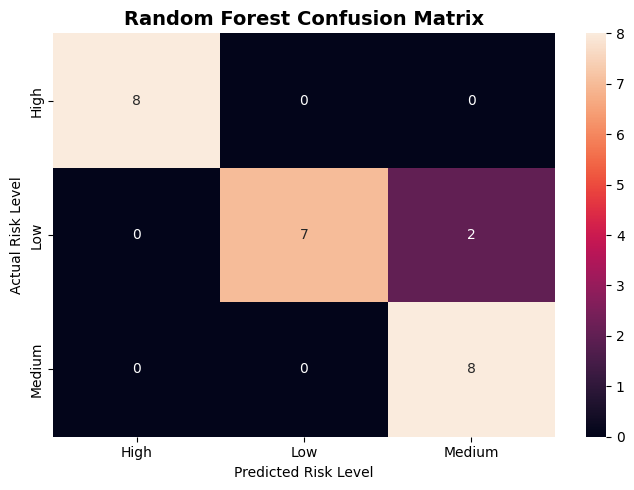

Feature Importance


,feature,importance
11,health_risk_score,0.233454
1,under_5_mortality_rate,0.161747
12,readiness_score,0.152022
0,infant_mortality_rate,0.120118
2,maternal_mortality_rate,0.101216
9,nurses_midwives_density,0.056222
5,undernourished_population,0.049386
4,tb_prevalence,0.030866
3,malaria_prevalence,0.028416
10,physicians_density,0.025941


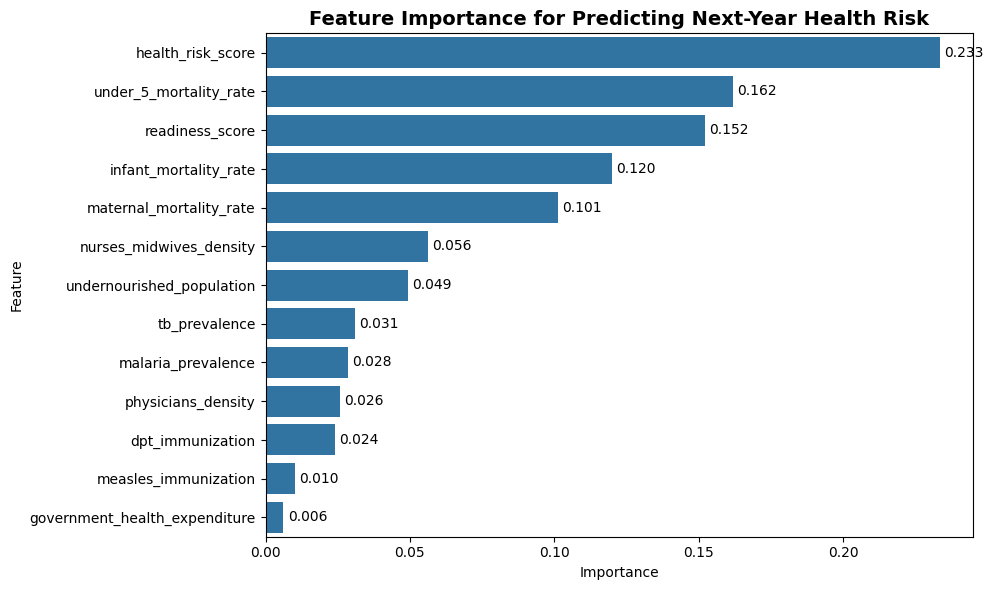

In [120]:
# ============================================================
# ML Step 2: Select Features and Train First Models
# Target: next_risk_level
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Make a copy
# ------------------------------------------------------------

model_df = ml_df.copy()

# ------------------------------------------------------------
# 2. Define target
# ------------------------------------------------------------

target = "next_risk_level"

# ------------------------------------------------------------
# 3. Define features
# ------------------------------------------------------------

features = [
    # Direct health risk indicators
    "infant_mortality_rate",
    "under_5_mortality_rate",
    "maternal_mortality_rate",
    "malaria_prevalence",
    "tb_prevalence",
    "undernourished_population",

    # Health system readiness indicators
    "government_health_expenditure",
    "dpt_immunization",
    "measles_immunization",
    "nurses_midwives_density",
    "physicians_density",

    # Current-year summary scores
    "health_risk_score",
    "readiness_score"
]

# ------------------------------------------------------------
# 4. Confirm all columns exist
# ------------------------------------------------------------

required_cols = features + [target]

missing_cols = [col for col in required_cols if col not in model_df.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are available.")

# ------------------------------------------------------------
# 5. Prepare X and y
# ------------------------------------------------------------

X = model_df[features]
y = model_df[target]

# Encode target labels: Low, Medium, High
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target classes:", list(label_encoder.classes_))

# ------------------------------------------------------------
# 6. Train-test split
# ------------------------------------------------------------
# Stratify helps preserve Low/Medium/High distribution in train and test.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

# ------------------------------------------------------------
# 7. Baseline Model: Logistic Regression
# ------------------------------------------------------------

log_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)

print("======================================")
print("LOGISTIC REGRESSION RESULTS")
print("======================================")
print("Accuracy:", round(accuracy_score(y_test, log_preds), 3))
print()
print(classification_report(
    y_test,
    log_preds,
    target_names=label_encoder.classes_
))

# ------------------------------------------------------------
# 8. Main Model: Random Forest Classifier
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("======================================")
print("RANDOM FOREST RESULTS")
print("======================================")
print("Accuracy:", round(accuracy_score(y_test, rf_preds), 3))
print()
print(classification_report(
    y_test,
    rf_preds,
    target_names=label_encoder.classes_
))

# ------------------------------------------------------------
# 9. Confusion Matrix for Random Forest
# ------------------------------------------------------------

cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Random Forest Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Risk Level")
plt.ylabel("Actual Risk Level")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Feature Importance
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Feature Importance")
display(feature_importance)

# ------------------------------------------------------------
# 11. Plot Feature Importance
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.title(
    "Feature Importance for Predicting Next-Year Health Risk",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Time-Based Validation

This will prove whether the model can predict future years, not just random country-year observations.

Training years: 2004 - 2011
Testing years: 2012 - 2013
Training rows: 80
Testing rows: 20
TIME-BASED LOGISTIC REGRESSION RESULTS
Accuracy: 0.95

              precision    recall  f1-score   support

         Low       0.88      1.00      0.93         7
      Medium       1.00      0.89      0.94         9
        High       1.00      1.00      1.00         4

    accuracy                           0.95        20
   macro avg       0.96      0.96      0.96        20
weighted avg       0.96      0.95      0.95        20

TIME-BASED RANDOM FOREST RESULTS
Accuracy: 0.95

              precision    recall  f1-score   support

         Low       0.88      1.00      0.93         7
      Medium       1.00      0.89      0.94         9
        High       1.00      1.00      1.00         4

    accuracy                           0.95        20
   macro avg       0.96      0.96      0.96        20
weighted avg       0.96      0.95      0.95        20



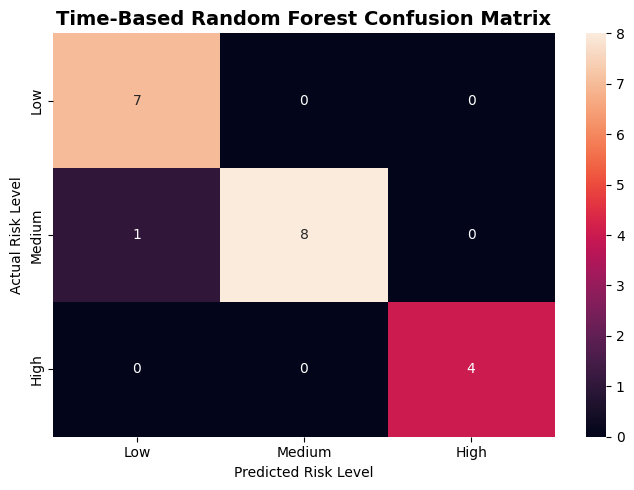

Time-Based Random Forest Feature Importance


,feature,importance
11,health_risk_score,0.230214
1,under_5_mortality_rate,0.211620
0,infant_mortality_rate,0.133629
2,maternal_mortality_rate,0.117228
12,readiness_score,0.102039
5,undernourished_population,0.040728
10,physicians_density,0.038940
9,nurses_midwives_density,0.038145
3,malaria_prevalence,0.031078
7,dpt_immunization,0.026832


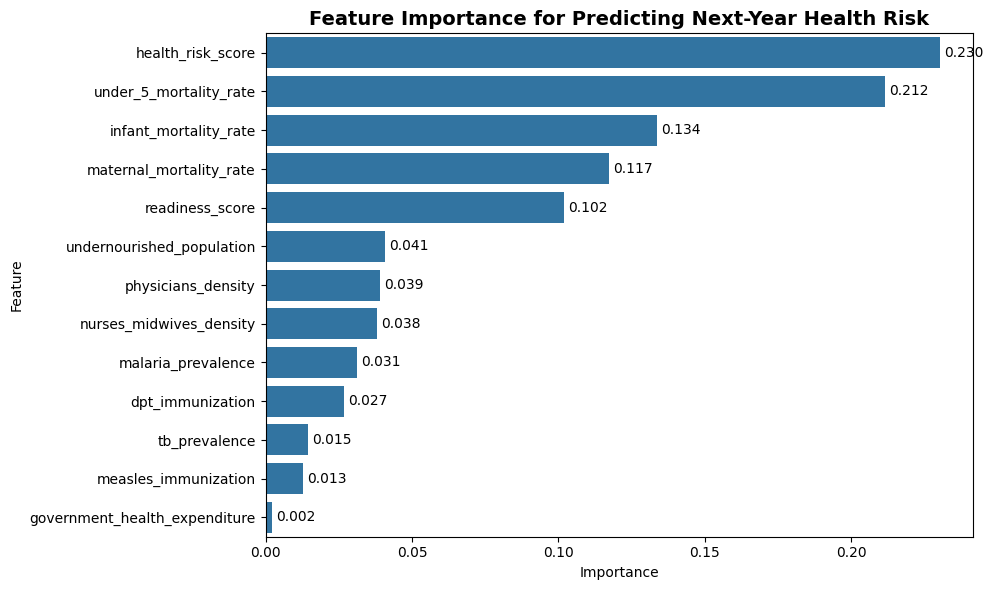

In [121]:
# ============================================================
# ML Step 3: Time-Based Validation
# Train on earlier years, test on later years
# ============================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Make a copy
# ------------------------------------------------------------

time_df = ml_df.copy()

time_df["year"] = time_df["year"].astype(int)

# ------------------------------------------------------------
# 2. Define features and target
# ------------------------------------------------------------

features = [
    "infant_mortality_rate",
    "under_5_mortality_rate",
    "maternal_mortality_rate",
    "malaria_prevalence",
    "tb_prevalence",
    "undernourished_population",
    "government_health_expenditure",
    "dpt_immunization",
    "measles_immunization",
    "nurses_midwives_density",
    "physicians_density",
    "health_risk_score",
    "readiness_score"
]

target = "next_risk_level"

# ------------------------------------------------------------
# 3. Encode target manually in logical order
# ------------------------------------------------------------

risk_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

reverse_risk_mapping = {
    0: "Low",
    1: "Medium",
    2: "High"
}

time_df["target_encoded"] = time_df[target].map(risk_mapping)

# ------------------------------------------------------------
# 4. Time-based split
# ------------------------------------------------------------
# Features from 2004-2011 predict 2005-2012
# Features from 2012-2013 predict 2013-2014

train_df = time_df[time_df["year"] <= 2011].copy()
test_df = time_df[time_df["year"] >= 2012].copy()

X_train = train_df[features]
y_train = train_df["target_encoded"]

X_test = test_df[features]
y_test = test_df["target_encoded"]

print("Training years:", train_df["year"].min(), "-", train_df["year"].max())
print("Testing years:", test_df["year"].min(), "-", test_df["year"].max())
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

# ------------------------------------------------------------
# 5. Baseline model: Logistic Regression
# ------------------------------------------------------------

log_time_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

log_time_model.fit(X_train, y_train)

log_time_preds = log_time_model.predict(X_test)

print("======================================")
print("TIME-BASED LOGISTIC REGRESSION RESULTS")
print("======================================")
print("Accuracy:", round(accuracy_score(y_test, log_time_preds), 3))
print()
print(classification_report(
    y_test,
    log_time_preds,
    target_names=["Low", "Medium", "High"]
))

# ------------------------------------------------------------
# 6. Main model: Random Forest
# ------------------------------------------------------------

rf_time_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

rf_time_model.fit(X_train, y_train)

rf_time_preds = rf_time_model.predict(X_test)

print("======================================")
print("TIME-BASED RANDOM FOREST RESULTS")
print("======================================")
print("Accuracy:", round(accuracy_score(y_test, rf_time_preds), 3))
print()
print(classification_report(
    y_test,
    rf_time_preds,
    target_names=["Low", "Medium", "High"]
))

# ------------------------------------------------------------
# 7. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, rf_time_preds, labels=[0, 1, 2])

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title(
    "Time-Based Random Forest Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Risk Level")
plt.ylabel("Actual Risk Level")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Feature Importance
# ------------------------------------------------------------

feature_importance_time = pd.DataFrame({
    "feature": features,
    "importance": rf_time_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Time-Based Random Forest Feature Importance")
display(feature_importance_time)

# ------------------------------------------------------------
# 9. Plot Feature Importance
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=feature_importance_time,
    x="importance",
    y="feature"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.title(
    "Feature Importance for Predicting Next-Year Health Risk",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Rank Feature	Meaning
1	health_risk_score	Current risk level is the strongest signal of next-year risk
2	under_5_mortality_rate	Child mortality is a major driver
3	infant_mortality_rate	Infant health burden matters strongly
4	maternal_mortality_rate	Maternal health risk is important
5	readiness_score	System capacity also helps predict risk

This is a very good story:

Countries with high current health risk, high child mortality, high infant mortality, high maternal mortality, and weaker readiness are more likely to remain or become high risk in the following year.

Robustness Model Without Summary Scores

Training years: 2004 - 2011
Testing years: 2012 - 2013
Training rows: 80
Testing rows: 20
RAW-INDICATOR LOGISTIC REGRESSION
Accuracy: 0.95

              precision    recall  f1-score   support

         Low       0.88      1.00      0.93         7
      Medium       1.00      0.89      0.94         9
        High       1.00      1.00      1.00         4

    accuracy                           0.95        20
   macro avg       0.96      0.96      0.96        20
weighted avg       0.96      0.95      0.95        20

RAW-INDICATOR RANDOM FOREST
Accuracy: 0.85

              precision    recall  f1-score   support

         Low       0.88      1.00      0.93         7
      Medium       0.80      0.89      0.84         9
        High       1.00      0.50      0.67         4

    accuracy                           0.85        20
   macro avg       0.89      0.80      0.81        20
weighted avg       0.87      0.85      0.84        20



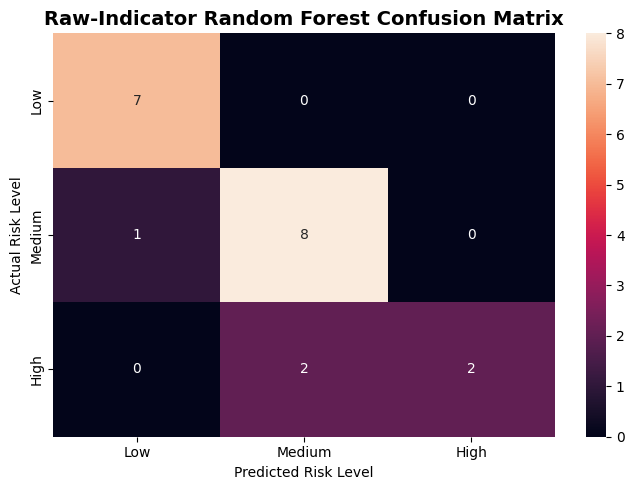

Raw-Indicator Feature Importance


,feature,importance
1,under_5_mortality_rate,0.267934
2,maternal_mortality_rate,0.211527
0,infant_mortality_rate,0.146777
9,nurses_midwives_density,0.090483
5,undernourished_population,0.064497
10,physicians_density,0.055011
7,dpt_immunization,0.053600
3,malaria_prevalence,0.053289
4,tb_prevalence,0.029037
8,measles_immunization,0.022386


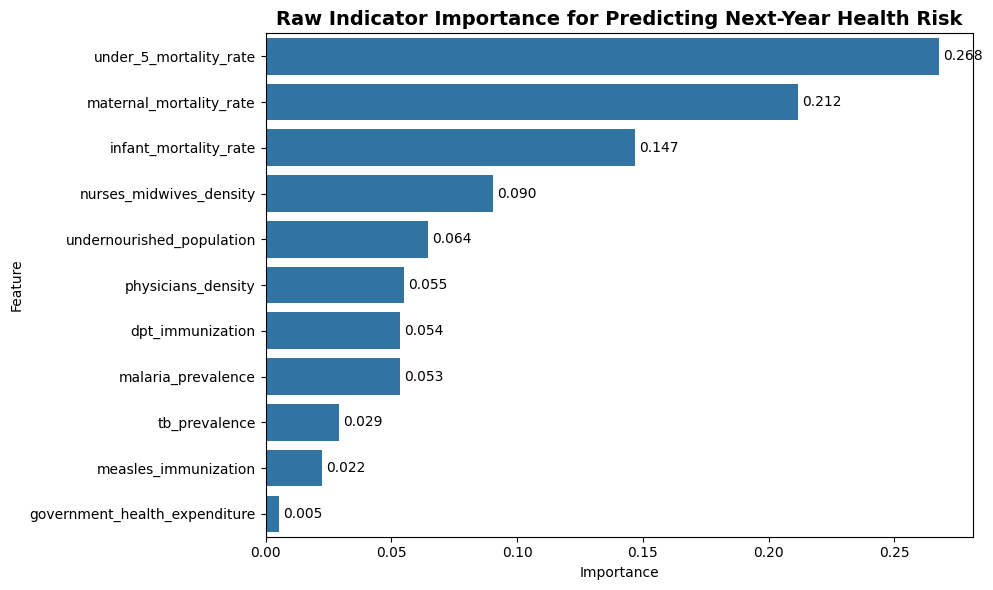

In [122]:
# ============================================================
# ML Step 4: Robustness Model Using Raw Indicators Only
# Target: next_risk_level
# ============================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Make a copy
# ------------------------------------------------------------

robust_df = ml_df.copy()
robust_df["year"] = robust_df["year"].astype(int)

# ------------------------------------------------------------
# 2. Raw indicator features only
# ------------------------------------------------------------

raw_features = [
    "infant_mortality_rate",
    "under_5_mortality_rate",
    "maternal_mortality_rate",
    "malaria_prevalence",
    "tb_prevalence",
    "undernourished_population",
    "government_health_expenditure",
    "dpt_immunization",
    "measles_immunization",
    "nurses_midwives_density",
    "physicians_density"
]

target = "next_risk_level"

# ------------------------------------------------------------
# 3. Encode target
# ------------------------------------------------------------

risk_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

robust_df["target_encoded"] = robust_df[target].map(risk_mapping)

# ------------------------------------------------------------
# 4. Time-based split
# Train on 2004-2011, test on 2012-2013
# ------------------------------------------------------------

train_df = robust_df[robust_df["year"] <= 2011].copy()
test_df = robust_df[robust_df["year"] >= 2012].copy()

X_train = train_df[raw_features]
y_train = train_df["target_encoded"]

X_test = test_df[raw_features]
y_test = test_df["target_encoded"]

print("Training years:", train_df["year"].min(), "-", train_df["year"].max())
print("Testing years:", test_df["year"].min(), "-", test_df["year"].max())
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

# ------------------------------------------------------------
# 5. Logistic Regression baseline
# ------------------------------------------------------------

log_raw_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

log_raw_model.fit(X_train, y_train)

log_raw_preds = log_raw_model.predict(X_test)

print("======================================")
print("RAW-INDICATOR LOGISTIC REGRESSION")
print("======================================")
print("Accuracy:", round(accuracy_score(y_test, log_raw_preds), 3))
print()
print(classification_report(
    y_test,
    log_raw_preds,
    target_names=["Low", "Medium", "High"]
))

# ------------------------------------------------------------
# 6. Random Forest raw-indicator model
# ------------------------------------------------------------

rf_raw_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

rf_raw_model.fit(X_train, y_train)

rf_raw_preds = rf_raw_model.predict(X_test)

print("======================================")
print("RAW-INDICATOR RANDOM FOREST")
print("======================================")
print("Accuracy:", round(accuracy_score(y_test, rf_raw_preds), 3))
print()
print(classification_report(
    y_test,
    rf_raw_preds,
    target_names=["Low", "Medium", "High"]
))

# ------------------------------------------------------------
# 7. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, rf_raw_preds, labels=[0, 1, 2])

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title(
    "Raw-Indicator Random Forest Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Risk Level")
plt.ylabel("Actual Risk Level")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Feature Importance
# ------------------------------------------------------------

raw_feature_importance = pd.DataFrame({
    "feature": raw_features,
    "importance": rf_raw_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Raw-Indicator Feature Importance")
display(raw_feature_importance)

# ------------------------------------------------------------
# 9. Plot Feature Importance
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=raw_feature_importance,
    x="importance",
    y="feature"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.title(
    "Raw Indicator Importance for Predicting Next-Year Health Risk",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

So our final ML story becomes:

We tested both baseline and tree-based models. The raw-indicator Logistic Regression model was selected as the final model because it achieved 95% time-based validation accuracy while using only the original health indicators. 

This makes the model both accurate and interpretable.

For the predictive modeling stage, the dataset was structured as an early-warning system where each country-year observation predicts the following year’s health risk level. Two modeling strategies were tested: models using both raw indicators and summary scores, and models using only raw health indicators.

The raw-indicator Logistic Regression model was selected as the final predictive model because it achieved 95% accuracy under time-based validation while relying only on original public health indicators. This makes the model more interpretable and avoids overdependence on the constructed Health Risk Score. 

The model successfully identified all High-risk cases in the test period, which is especially important for public health decision-making because missing high-risk countries could delay urgent intervention.


In [123]:
# ============================================================
# Save Final Model: Raw-Indicator Logistic Regression
# ============================================================

import joblib
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# 1. Prepare final model dataset
# ------------------------------------------------------------

final_model_df = ml_df.copy()
final_model_df["year"] = final_model_df["year"].astype(int)

# ------------------------------------------------------------
# 2. Define final features
# ------------------------------------------------------------

final_features = [
    "infant_mortality_rate",
    "under_5_mortality_rate",
    "maternal_mortality_rate",
    "malaria_prevalence",
    "tb_prevalence",
    "undernourished_population",
    "government_health_expenditure",
    "dpt_immunization",
    "measles_immunization",
    "nurses_midwives_density",
    "physicians_density"
]

target = "next_risk_level"

# ------------------------------------------------------------
# 3. Encode target
# ------------------------------------------------------------

risk_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

reverse_risk_mapping = {
    0: "Low",
    1: "Medium",
    2: "High"
}

final_model_df["target_encoded"] = final_model_df[target].map(risk_mapping)

X_final = final_model_df[final_features]
y_final = final_model_df["target_encoded"]

# ------------------------------------------------------------
# 4. Train final model on all available ML rows
# ------------------------------------------------------------

final_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

final_model.fit(X_final, y_final)

# ------------------------------------------------------------
# 5. Save model and useful objects
# ------------------------------------------------------------

joblib.dump(final_model, "healthpulse_final_model.pkl")
joblib.dump(final_features, "healthpulse_model_features.pkl")
joblib.dump(reverse_risk_mapping, "healthpulse_risk_label_mapping.pkl")

print("Final model saved successfully.")

Final model saved successfully.


AI Recommendation Layer

In [124]:
# ============================================================
# AI Recommendation Layer for HealthPulse AI
# ============================================================

import pandas as pd
import numpy as np
import joblib

# ------------------------------------------------------------
# 1. Load final model and useful objects
# ------------------------------------------------------------

final_model = joblib.load("healthpulse_final_model.pkl")
final_features = joblib.load("healthpulse_model_features.pkl")
reverse_risk_mapping = joblib.load("healthpulse_risk_label_mapping.pkl")

# ------------------------------------------------------------
# 2. Prepare prediction data
# ------------------------------------------------------------
# We will use the latest available year, 2014, as the demo prediction year.

prediction_df = health_df.copy()
prediction_df["year"] = prediction_df["year"].astype(int)

latest_year = prediction_df["year"].max()

latest_df = prediction_df[prediction_df["year"] == latest_year].copy()

X_latest = latest_df[final_features]

# ------------------------------------------------------------
# 3. Predict next risk level
# ------------------------------------------------------------

latest_df["predicted_risk_encoded"] = final_model.predict(X_latest)

latest_df["predicted_risk_level"] = latest_df["predicted_risk_encoded"].map(
    reverse_risk_mapping
)

# Predict probabilities
risk_probabilities = final_model.predict_proba(X_latest)

# Get class names in correct encoded order
class_names = [reverse_risk_mapping[i] for i in final_model.classes_]

probability_df = pd.DataFrame(
    risk_probabilities,
    columns=[f"prob_{name.lower()}" for name in class_names]
)

latest_df = latest_df.reset_index(drop=True)
latest_df = pd.concat([latest_df, probability_df], axis=1)

# ------------------------------------------------------------
# 4. Define indicator direction logic
# ------------------------------------------------------------

risk_indicators = [
    "infant_mortality_rate",
    "under_5_mortality_rate",
    "maternal_mortality_rate",
    "malaria_prevalence",
    "tb_prevalence",
    "undernourished_population"
]

readiness_indicators = [
    "government_health_expenditure",
    "dpt_immunization",
    "measles_immunization",
    "nurses_midwives_density",
    "physicians_density"
]

# Median values from the full dataset
indicator_medians = health_df[final_features].median()

# ------------------------------------------------------------
# 5. Function to identify top concern indicators
# ------------------------------------------------------------

def identify_concerns(row, top_n=5):
    concerns = []

    # Bad indicators: higher than median means concern
    for col in risk_indicators:
        value = row[col]
        median_value = indicator_medians[col]

        if value > median_value:
            gap = value - median_value
            concerns.append({
                "indicator": col,
                "value": value,
                "median": median_value,
                "gap": gap,
                "direction": "High",
                "message": f"{col} is above the ASEAN median"
            })

    # Good indicators: lower than median means concern
    for col in readiness_indicators:
        value = row[col]
        median_value = indicator_medians[col]

        if value < median_value:
            gap = median_value - value
            concerns.append({
                "indicator": col,
                "value": value,
                "median": median_value,
                "gap": gap,
                "direction": "Low",
                "message": f"{col} is below the ASEAN median"
            })

    concerns = sorted(concerns, key=lambda x: x["gap"], reverse=True)

    return concerns[:top_n]

# ------------------------------------------------------------
# 6. Function to generate policy recommendations
# ------------------------------------------------------------

def generate_recommendations(concerns):
    actions = []

    concern_indicators = [item["indicator"] for item in concerns]

    if "under_5_mortality_rate" in concern_indicators or "infant_mortality_rate" in concern_indicators:
        actions.append(
            "Strengthen child health services, expand immunization outreach, and improve early childhood disease screening."
        )

    if "maternal_mortality_rate" in concern_indicators:
        actions.append(
            "Prioritize maternal health services, emergency obstetric care, and deployment of skilled birth attendants."
        )

    if "malaria_prevalence" in concern_indicators:
        actions.append(
            "Expand malaria surveillance, vector control, rapid testing, and community-level prevention campaigns."
        )

    if "tb_prevalence" in concern_indicators:
        actions.append(
            "Scale up TB screening, case detection, treatment adherence support, and community health monitoring."
        )

    if "undernourished_population" in concern_indicators:
        actions.append(
            "Integrate nutrition support with maternal and child health programs, especially in vulnerable communities."
        )

    if "dpt_immunization" in concern_indicators or "measles_immunization" in concern_indicators:
        actions.append(
            "Launch targeted vaccine catch-up campaigns and strengthen routine immunization systems."
        )

    if "nurses_midwives_density" in concern_indicators:
        actions.append(
            "Increase nurses and midwives deployment, especially in underserved and rural health facilities."
        )

    if "physicians_density" in concern_indicators:
        actions.append(
            "Improve physician availability through mobile clinics, telemedicine support, and rural service incentives."
        )

    if "government_health_expenditure" in concern_indicators:
        actions.append(
            "Increase targeted public health financing toward high-burden disease areas and frontline healthcare delivery."
        )

    if len(actions) == 0:
        actions.append(
            "Maintain current health investments, continue surveillance, and monitor early warning indicators."
        )

    return actions

# ------------------------------------------------------------
# 7. Function to create final AI-style explanation
# ------------------------------------------------------------

def create_ai_summary(row):
    concerns = identify_concerns(row, top_n=5)
    actions = generate_recommendations(concerns)

    top_concerns_text = []
    for i, concern in enumerate(concerns, start=1):
        readable_indicator = concern["indicator"].replace("_", " ")
        top_concerns_text.append(
            f"{i}. {readable_indicator}: {concern['message']}."
        )

    actions_text = []
    for i, action in enumerate(actions, start=1):
        actions_text.append(f"{i}. {action}")

    summary = f"""
Country: {row['country']}
Year assessed: {row['year']}
Predicted next-year health risk level: {row['predicted_risk_level']}

Main risk signals:
{chr(10).join(top_concerns_text)}

Recommended public health actions:
{chr(10).join(actions_text)}
"""

    return summary.strip()

# ------------------------------------------------------------
# 8. Apply AI recommendation engine
# ------------------------------------------------------------

latest_df["top_concerns"] = latest_df.apply(
    lambda row: identify_concerns(row, top_n=5),
    axis=1
)

latest_df["recommendations"] = latest_df["top_concerns"].apply(
    generate_recommendations
)

latest_df["ai_summary"] = latest_df.apply(
    create_ai_summary,
    axis=1
)

# ------------------------------------------------------------
# 9. Create clean output table
# ------------------------------------------------------------

ai_output = latest_df[
    [
        "country",
        "year",
        "health_risk_score",
        "health_risk_level",
        "readiness_score",
        "readiness_level",
        "priority_category",
        "predicted_risk_level",
        "prob_low",
        "prob_medium",
        "prob_high",
        "ai_summary"
    ]
].copy()

ai_output = ai_output.sort_values(
    by=["predicted_risk_level", "prob_high"],
    ascending=[True, False]
)

ai_output.head()

,country,year,health_risk_score,health_risk_level,readiness_score,readiness_level,priority_category,predicted_risk_level,prob_low,prob_medium,prob_high,ai_summary
1,Cambodia,2014,34.853070,High,37.877577,Low,Emergency Priority,High,0.000095,0.093010,9.068950e-01,Country: Cambodia\nYear assessed: 2014\nPredic...
3,Lao PDR,2014,37.142557,High,32.556521,Low,Emergency Priority,High,0.000002,0.152114,8.478841e-01,Country: Lao PDR\nYear assessed: 2014\nPredict...
8,Thailand,2014,5.569113,Low,58.250091,High,Stable / Resilient,Low,0.623073,0.376398,5.288852e-04,Country: Thailand\nYear assessed: 2014\nPredic...
4,Malaysia,2014,3.824048,Low,61.085077,High,Stable / Resilient,Low,0.922288,0.077691,2.100044e-05,Country: Malaysia\nYear assessed: 2014\nPredic...
7,Singapore,2014,4.805894,Low,81.042520,High,Stable / Resilient,Low,0.973301,0.026698,9.957440e-07,Country: Singapore\nYear assessed: 2014\nPredi...


In [125]:
print(ai_output.loc[0, "ai_summary"])

Country: Brunei Darussalam
Year assessed: 2014
Predicted next-year health risk level: Low

Main risk signals:
1. government health expenditure: government_health_expenditure is below the ASEAN median.
2. tb prevalence: tb_prevalence is above the ASEAN median.

Recommended public health actions:
1. Scale up TB screening, case detection, treatment adherence support, and community health monitoring.
2. Increase targeted public health financing toward high-burden disease areas and frontline healthcare delivery.


In [126]:
for i in range(len(ai_output)):
    print("=" * 80)
    print(ai_output.loc[i, "ai_summary"])
    print()

Country: Brunei Darussalam
Year assessed: 2014
Predicted next-year health risk level: Low

Main risk signals:
1. government health expenditure: government_health_expenditure is below the ASEAN median.
2. tb prevalence: tb_prevalence is above the ASEAN median.

Recommended public health actions:
1. Scale up TB screening, case detection, treatment adherence support, and community health monitoring.
2. Increase targeted public health financing toward high-burden disease areas and frontline healthcare delivery.

Country: Cambodia
Year assessed: 2014
Predicted next-year health risk level: High

Main risk signals:
1. tb prevalence: tb_prevalence is above the ASEAN median.
2. malaria prevalence: malaria_prevalence is above the ASEAN median.
3. government health expenditure: government_health_expenditure is below the ASEAN median.
4. maternal mortality rate: maternal_mortality_rate is above the ASEAN median.
5. under 5 mortality rate: under_5_mortality_rate is above the ASEAN median.

Recommen

In [127]:
ai_output.to_csv("healthpulse_ai_recommendations.csv", index=False)
print("AI recommendation output saved successfully.")

AI recommendation output saved successfully.


In [128]:
# ============================================================
# Clean table for dashboard or presentation
# ============================================================

dashboard_output = ai_output[
    [
        "country",
        "year",
        "health_risk_score",
        "health_risk_level",
        "readiness_score",
        "readiness_level",
        "priority_category",
        "predicted_risk_level",
        "prob_low",
        "prob_medium",
        "prob_high"
    ]
].copy()

dashboard_output["prob_low"] = dashboard_output["prob_low"].round(3)
dashboard_output["prob_medium"] = dashboard_output["prob_medium"].round(3)
dashboard_output["prob_high"] = dashboard_output["prob_high"].round(3)
dashboard_output["health_risk_score"] = dashboard_output["health_risk_score"].round(2)
dashboard_output["readiness_score"] = dashboard_output["readiness_score"].round(2)

dashboard_output = dashboard_output.sort_values(
    by=["prob_high", "health_risk_score"],
    ascending=False
)

dashboard_output

,country,year,health_risk_score,health_risk_level,readiness_score,readiness_level,priority_category,predicted_risk_level,prob_low,prob_medium,prob_high
1,Cambodia,2014,34.85,High,37.88,Low,Emergency Priority,High,0.000,0.093,0.907
3,Lao PDR,2014,37.14,High,32.56,Low,Emergency Priority,High,0.000,0.152,0.848
5,Myanmar,2014,22.70,Medium,42.63,Medium,Moderate Priority,Medium,0.003,0.888,0.110
2,Indonesia,2014,21.38,Medium,47.11,Medium,Moderate Priority,Medium,0.008,0.936,0.056
6,Philippines,2014,17.88,Medium,58.80,High,Controlled Risk,Medium,0.119,0.877,0.004
9,Viet Nam,2014,12.82,Medium,57.93,High,Controlled Risk,Medium,0.255,0.743,0.002
8,Thailand,2014,5.57,Low,58.25,High,Stable / Resilient,Low,0.623,0.376,0.001
0,Brunei Darussalam,2014,4.92,Low,73.92,High,Stable / Resilient,Low,0.994,0.006,0.000
7,Singapore,2014,4.81,Low,81.04,High,Stable / Resilient,Low,0.973,0.027,0.000
4,Malaysia,2014,3.82,Low,61.09,High,Stable / Resilient,Low,0.922,0.078,0.000


In [129]:
dashboard_output.to_csv("healthpulse_dashboard_output.csv", index=False)

The AI recommendation layer converts model predictions into actionable public health guidance. After predicting each country’s next-year health risk level, the system compares key health and readiness indicators against ASEAN median values to identify the strongest concern areas. 

Indicators such as high child mortality, high maternal mortality, high disease prevalence, low immunization coverage, weak health workforce density, and low health expenditure are translated into targeted public health recommendations. 

This allows HealthPulse AI to move beyond prediction and support decision-making for resource allocation, prevention, and emergency response.
